# Crypto Direction Classification — End-to-End ML Refresher

A complete, hands-on refresher for the **classification** workflow applied to cryptocurrency
markets. You will predict the **direction (up/down) of BTC's next 4-hour return** using
hourly OHLCV features from BTC, ETH, SOL, and BNB.

Each major section contains:
1. A teaching walkthrough with code + explanations.
2. Hands-on **exercises** with hidden solutions (click the toggle to reveal).

Treat this notebook as a workbook. Try every exercise yourself before peeking.

## 0. Setup & Imports

Standard imports plus a fixed random seed for reproducibility. Plots use a clean
seaborn style with consistent figure sizing.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

DATA_PATH = "./../data/crypto_hourly.parquet"
print("Setup complete. NumPy", np.__version__, "Pandas", pd.__version__)

Setup complete. NumPy 2.4.4 Pandas 2.3.3


## 0.1 Problem Framing

**Target**: For each hourly timestamp `t`, predict whether BTC's close 4 hours later is
higher than the current close:

$$ y_t = \mathbb{1}\big[ \text{close}^{BTC}_{t+4} > \text{close}^{BTC}_t \big] $$

**Why classification, not regression?**
- Direction is more robust than magnitude in noisy markets.
- Threshold tuning gives explicit control over precision/recall trade-offs.
- A binary signal maps cleanly onto downstream long/flat or long/short rules.

**Leakage rule**: Every feature at time `t` MUST be computable using only information
available **at or before** `t`. We never use future bars to engineer features. We will
sanity-check this explicitly.

---
## Stage 1 — Data Quality

**↳ Why we're here.** Every model downstream — every metric, every backtest, every P&L estimate — assumes the input dataframe is a contiguous, deduplicated, properly-typed time series. If a single symbol has a 3-hour gap halfway through, every rolling statistic computed across that gap is silently wrong. If two timestamps duplicate, group-by-symbol counts disagree with date-range counts. **None of these problems raise an exception** — they produce *plausible but lying* output, which we then train models on. By the time we notice the model is "weirdly good", we've wasted weeks.

This stage's job is to prove the data is sound *before* building anything on top of it. We produce two artifacts that the rest of the pipeline depends on:

1. A long-format frame `df` whose `(ts, symbol)` pairs are unique, sorted chronologically inside each symbol, with all expected columns and no surprise NaNs.
2. A reusable **data quality report** function that asserts those properties — so the next time someone (you in two months, or an upstream ETL) breaks them, the pipeline crashes instead of producing fictional results.

We start by loading the raw long-format dataframe (one row per symbol-timestamp).


In [2]:
df = pd.read_parquet(DATA_PATH)
df["ts"] = pd.to_datetime(df["ts"], utc=True)
df = df.sort_values(["symbol", "ts"]).reset_index(drop=True)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Time range:", df["ts"].min(), "->", df["ts"].max())
df.head()

Shape: (70080, 7)
Columns: ['ts', 'open', 'high', 'low', 'close', 'volume', 'symbol']
Time range: 2024-04-19 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00


,ts,open,high,low,close,volume,symbol
0,2024-04-19 23:00:00+00:00,556.7,557.0,549.6,554.0,21953.020,BNB
1,2024-04-20 00:00:00+00:00,554.1,557.1,551.2,551.4,14108.411,BNB
2,2024-04-20 01:00:00+00:00,551.3,557.4,548.8,556.9,12407.915,BNB
3,2024-04-20 02:00:00+00:00,556.9,558.1,554.7,557.0,7299.961,BNB
4,2024-04-20 03:00:00+00:00,557.1,558.1,555.6,556.5,5680.975,BNB


In [3]:
print("Per-symbol row counts:")
print(df.groupby("symbol").size())
print("\nPer-symbol date span:")
print(df.groupby("symbol")["ts"].agg(["min", "max"]))
print("\nMissing values per column:")
print(df.isna().sum())

Per-symbol row counts:
symbol
BNB    17520
BTC    17520
ETH    17520
SOL    17520
dtype: int64

Per-symbol date span:
                             min                       max
symbol                                                    
BNB    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00
BTC    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00
ETH    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00
SOL    2024-04-19 23:00:00+00:00 2026-04-19 22:00:00+00:00

Missing values per column:
ts        0
open      0
high      0
low       0
close     0
volume    0
symbol    0
dtype: int64


### The 30-second concept

Three pandas patterns do 90% of the data-quality work in a real pipeline:

```python
# 1. Per-group statistics over time using groupby.apply + diff
df.groupby('symbol')['ts'].apply(lambda s: s.sort_values().diff().dt.total_seconds().div(3600).max())
# → Series indexed by symbol; value = the largest gap in hours

# 2. Long → wide reshape
df.pivot(index='ts', columns='symbol', values='close').sort_index()
# → DataFrame with one column per symbol; rectangular, easy to feature-engineer

# 3. Continuity check via expected-grid + reindex
expected = pd.date_range(df['ts'].min(), df['ts'].max(), freq='1h', tz='UTC')
wide.reindex(expected).isna().sum()
# → Per-symbol count of missing bars
```

The *why* behind these specific choices:

- **`groupby(...).apply` rather than a Python loop.** Pandas is two orders of magnitude faster on real data. More importantly, it forces you to think about per-group operations in a vectorised way — that mindset transfers to every later stage.
- **`pivot` rather than concat-and-merge.** Pivot gives you a single rectangular array. Feature engineering downstream (rolling means, cross-asset correlations, lag features) becomes a one-liner per feature. With long-format data, every feature needs its own per-group apply.
- **`reindex` against an expected grid, not the timestamp column.** The *difference between actual and expected* is the missing-data signal. Just trusting whatever timestamps shipped tells you nothing about the bars you didn't observe.

`.sort_values()` inside the lambda and `.sort_index()` after pivot look redundant (both are sorted in current pandas), but they are *defensive* habits. If the source ever ships timestamps out of order — and at some point it will — every `.shift()` and `.rolling()` downstream will silently corrupt without them.


### Worked example — running the three patterns on a deliberately broken toy frame

We build a tiny 3-symbol frame, deliberately introduce a duplicate row, a gap, and a NaN, then run each idiom and watch what it surfaces. Read the comments — they explain not just *what* each line does, but *why* that line is the right tool for the job.


In [ ]:
import pandas as pd
import numpy as np

# Tiny toy with three deliberate problems.
toy = pd.DataFrame({
    'ts': pd.to_datetime([
        '2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 03:00',  # 'A' has a gap (no 02:00)
        '2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 02:00',
        '2024-01-01 00:00', '2024-01-01 00:00', '2024-01-01 02:00',  # 'C' has a duplicate at 00:00 and a missing 01:00
    ], utc=True),
    'symbol': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'close':  [100, 101, np.nan, 50, 51, 52, 30, 30.5, 32],   # 'A' also has a missing close
})

# 1. Largest gap per symbol — surfaces A's missing 02:00 bar.
#    Sorting INSIDE the lambda matters: groupby preserves first-row order, not
#    chronological order. A 2-row group with rows out of order would give a
#    *negative* timedelta — silently wrong.
gaps_h = toy.groupby('symbol')['ts'].apply(
    lambda s: s.sort_values().diff().dt.total_seconds().div(3600).max()
)
print('Largest gap per symbol (hours):')
print(gaps_h, '\n')

# 2. % missing per column — surfaces the NaN close in A.
#    Multiply by 100 so the output reads naturally as a percentage.
print('% missing per column:')
print((toy.isna().mean() * 100).round(2), '\n')

# 3. pivot WILL FAIL on duplicate (ts, symbol) pairs — and that's good.
#    A silent duplicate is far worse than a noisy crash; pivot's strictness
#    forces us to make a deliberate choice about how to dedupe.
try:
    toy.pivot(index='ts', columns='symbol', values='close')
except ValueError as e:
    print(f'pivot raised: {str(e)[:80]}...\n')

# Fix the duplicates explicitly: keep first observation per (ts, symbol).
# Alternatives in production: take the mean, or assert that duplicates are
# never expected (depends on the upstream contract).
toy_dedup = toy.drop_duplicates(subset=['ts', 'symbol'], keep='first')
wide_toy = toy_dedup.pivot(index='ts', columns='symbol', values='close').sort_index()
print('Wide pivot after dedup:')
print(wide_toy, '\n')

# 4. Continuity check via expected grid — surfaces the missing 01:00 row of C.
expected = pd.date_range(toy['ts'].min(), toy['ts'].max(), freq='1h', tz='UTC')
n_missing = wide_toy.reindex(expected).isna().sum()
print('Missing bars per symbol after reindex against the expected hourly grid:')
print(n_missing)

### Failure mode — what happens when you skip the wide-pivot and do the obvious thing instead

The naive way to compute per-symbol returns from a long frame:

```python
returns = df.groupby('symbol')['close'].apply(np.log).diff()
```

looks correct. **It isn't.** `.apply()` returns a flat Series; `.diff()` then operates on the *whole* series, ignoring group boundaries. At the row where one symbol's last bar gives way to the next symbol's first bar, you get `log(ETH_first) − log(BTC_last)` — a "return" between two different assets. Run the cell below before moving on.


In [ ]:
# 1. The naive (broken) version: groupby.apply followed by .diff() on the result.
bad_returns = df.groupby('symbol')['close'].apply(np.log).diff()

# 2. The correct version: pivot to wide first, then diff per column.
wide_close_demo = df.pivot(index='ts', columns='symbol', values='close').sort_index()
correct_returns_btc = np.log(wide_close_demo['BTC']).diff()

print('Naive cross-symbol "returns":')
print(f'  std        = {bad_returns.std():.4f}')
print(f'  max |ret|  = {bad_returns.abs().max():.4f}    ← look at this number\n')

print('Correct BTC returns:')
print(f'  std        = {correct_returns_btc.std():.4f}')
print(f'  max |ret|  = {correct_returns_btc.abs().max():.4f}\n')

ratio = bad_returns.abs().max() / correct_returns_btc.abs().max()
print(f'The naive version\'s biggest "return" is {ratio:.0f}× the largest real BTC return.')
print('That single garbage value is log(next_symbol_first / prev_symbol_last) at')
print('the symbol boundary. A volatility model trained on this would learn that')
print('returns are wildly larger than they really are; any "edge" it discovers')
print('comes from that one fictional spike. The model will look great in')
print('backtest and lose money in production.')

### Decisions you make at this stage

- **Drop, fill, or assert?** Dropping rows with missing data breaks downstream alignment if other symbols have data at the same timestamps — pivoting first lets you `NaN` one column without dropping the row. Filling (forward-fill, mean) introduces synthetic data that masks regime changes and inflates apparent precision. **Asserting** fails loudly, which is usually the right default at the prototype stage. Switch to filling only when you've quantified the impact on downstream metrics.

- **Per-symbol or jointly?** A gap in one symbol doesn't invalidate the others. Pivot first to a rectangular frame, *then* decide what to do per column.

- **Where to draw the failure threshold?** A single missing bar in 17,000 is fine. A 24-hour gap is not — the model will learn the wrong distribution of overnight moves. Codify these thresholds as numerical asserts (e.g. `assert max_gap_hours < 6`) so the next ETL regression trips the alarm instead of silently producing bad features.


### Exercise 1.1 — Build a data quality report

Real pipelines fail silently. The fix is to codify your assumptions as a **report**: a function that computes every quality metric you care about, and *asserts* against thresholds you can defend out loud.

Build `data_quality_report(df)` that returns a dict with these keys:

- `n_rows` — int
- `n_symbols` — int
- `max_gap_hours` — float, the largest per-symbol gap in hours
- `n_duplicate_rows` — int, count of duplicated `(ts, symbol)` pairs
- `pct_missing` — dict mapping column → percent missing (rounded to 2 dp)
- `n_missing_bars_per_symbol` — dict mapping symbol → number of bars missing from the expected hourly grid (after pivot + reindex)

Apply it to `df`. Print the report. Then write `assert` statements that would fail if any quality threshold is breached — pick the threshold values yourself and **justify them in a comment** (e.g. why 6 hours? why 5%? what would the impact be on downstream features?).


In [ ]:
def data_quality_report(df: pd.DataFrame) -> dict:
    # TODO: build the dict with the six keys above, reusing the three patterns
    # from the worked example.
    pass

report = data_quality_report(df)
print(report)

# TODO: add asserts with thresholds you can justify.
# assert ...

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def data_quality_report(df: pd.DataFrame) -> dict:
    wide = df.pivot(index='ts', columns='symbol', values='close').sort_index()
    expected = pd.date_range(df['ts'].min(), df['ts'].max(), freq='1h', tz='UTC')

    return {
        'n_rows': len(df),
        'n_symbols': df['symbol'].nunique(),
        'max_gap_hours': float(
            df.groupby('symbol')['ts']
              .apply(lambda s: s.sort_values().diff().dt.total_seconds().div(3600).max())
              .max()
        ),
        'n_duplicate_rows': int(df.duplicated(subset=['ts', 'symbol']).sum()),
        'pct_missing': (df.isna().mean() * 100).round(2).to_dict(),
        'n_missing_bars_per_symbol': wide.reindex(expected).isna().sum().to_dict(),
    }

report = data_quality_report(df)
print(report)

# Justified asserts:
#  - 6 h gap: anything longer crosses a typical overnight regime, which would
#    distort the distribution of "next-bar" returns the model learns from.
#  - duplicates: the upstream contract guarantees uniqueness, so any duplicate
#    is a bug in the join or the source — fix it now, not after model training.
#  - 5% missing per symbol: above this, the symbol's data is too sparse to
#    rely on without re-fetching.
n_bars_expected = len(pd.date_range(df['ts'].min(), df['ts'].max(), freq='1h', tz='UTC'))
assert report['max_gap_hours'] < 6, f"Suspicious gap: {report['max_gap_hours']:.1f}h"
assert report['n_duplicate_rows'] == 0, f"Duplicates: {report['n_duplicate_rows']}"
for sym, n_missing in report['n_missing_bars_per_symbol'].items():
    assert n_missing / n_bars_expected < 0.05, f"{sym} missing {n_missing} bars"
```

**Why this shape works.** Each key in the report is something a downstream stage *would silently fail on* if it regressed. By computing them all at the start of every run, you turn silent corruption into a noisy crash.

The asserts are *thresholds*, not absence-tests — picking them is a judgement call worth thinking about. Setting them too tight gives false alarms; too loose lets corruption through. A team standard might be to start strict (`< 1` hour gap) and relax only when the false-alarm rate justifies it.

**Why pivot-then-reindex inside the function**: it materialises both the actual and the expected grid in one place, making the missing-bar count a single subtraction. The alternative (a per-symbol loop) is slower and reads worse — and you'd write that loop inconsistently every time.

</details>


### Exercise 1.2 — Diagnose a buggy pipeline cell

The cell below tries to compute hourly log-returns for BTC. It runs without errors and produces a plausible-looking output. But there is a subtle bug that *could* silently corrupt every feature built on top of it. Run the cell, compare the output to the worked-example version above, identify the bug, and write the fixed version in the answer cell beneath.

(Hint: think about whether this code is correct *because of the data we happen to have*, or *because of the operations being performed*. The first kind of correctness breaks the moment the data changes shape.)


In [ ]:
# BUGGY — run me, then think about what assumption this code is relying on.
btc_rows = df[df['symbol'] == 'BTC']                    # filter to BTC
btc_returns_buggy = np.log(btc_rows['close']).diff()    # log-diff to get returns
print(f"buggy std:        {btc_returns_buggy.std():.6f}")
print(f"buggy max |ret|:  {btc_returns_buggy.abs().max():.4f}")
print(btc_returns_buggy.head(5))

In [ ]:
# Your answer here — write the FIXED version below.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
btc_rows = df[df['symbol'] == 'BTC'].sort_values('ts')   # ← critical: ensure chronological order
btc_returns_correct = np.log(btc_rows['close']).diff()
print(f"correct std:        {btc_returns_correct.std():.6f}")
print(f"correct max |ret|:  {btc_returns_correct.abs().max():.4f}")
```

**The bug.** Earlier in the notebook we wrote `df = df.sort_values(['symbol', 'ts'])` — sorted by *symbol first, then ts*. When you filter to BTC, the rows are still in `ts` order *only because BTC happens to come first alphabetically* and was sorted internally. The moment the source ships symbols in a different order — or you join with another frame that doesn't preserve order — the BTC slice could come back un-sorted, and `np.log(close).diff()` would compute "returns" between non-adjacent times.

**The fix.** An explicit `.sort_values('ts')` after the filter. It costs almost nothing and makes the line's correctness *not depend* on the ambient sort order of the parent frame.

**The general lesson.** Pipelines are correct when each step is correct *in isolation*, not when the steps happen to compose nicely *given the current data*. Any operation that depends on ordering, group boundaries, alignment, or dtype is suspect until proven otherwise. Defensive `.sort_index()` / `.sort_values()` / `.copy()` calls are cheap insurance — and they document the invariants the line is relying on. Future-you, looking at the line in isolation, should be able to see that it's correct.

</details>


### Recap — what stage 1 produced

You now have:

- `df` — long-format frame, sorted, deduplicated, hourly UTC timestamps verified.
- A reusable `data_quality_report(df)` function. Run it at the start of every pipeline run; if it fails, **stop**.
- A reflex for spotting silent corruption: *any operation that depends on ordering, group boundaries, or alignment is suspect until proven otherwise.* Defensive `sort_*` / `.copy()` calls are cheap insurance.

In **stage 2** we'll pivot `df` to wide format, compute returns, and look at their distributional properties — the inputs to every feature we'll engineer in stage 3.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had four exercises (1.1 — largest gap; 1.2 — % missing; 1.3 — pivot; 1.4 — continuity check). Their building blocks have been folded into Exercise 1.1 above (the data quality report). Your answers from the previous iteration are preserved here verbatim for reference.

**Old 1.1 — Largest time gap per symbol**

```python
# Your answer here
# Hint: groupby symbol, then compute diff() on ts within each group.

gaps_per_symbol = (
    df.sort_values(['ts', 'symbol'])
    .groupby('symbol')['ts']
    .apply(lambda t: t.diff().dt.total_seconds().div(3600).max())
)
gaps_per_symbol
```

**Old 1.2 — Percent missing per column**

```python
# Your answer here

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct
```

**Old 1.3 — Pivot to wide**

```python
# Your answer here

wide_close = df.pivot(columns='symbol', index='ts', values='close')
print(f"Shape: {wide_close.shape}")
wide_close.tail(3)
```

**Old 1.4 — Verify hourly continuity with reindex**

```python
# Your answer here

full_rng = pd.date_range(start=wide_close.index.min(), end=wide_close.index.max())
btc_full = wide_close['BTC'].reindex(full_rng)
print(f"No. missing bars: {btc_full.isna().sum()}")
```

</details>


---
## Stage 2 — Returns and Distributional EDA

**↳ Why we're here.** Stage 1 gave us a clean wide frame of prices. Before engineering features, we look at the data — *not to be thorough*, but to make downstream design decisions. EDA tells us:

- **What scale of price movement is normal?** Sets up the noise floor every model has to clear. If 99% of returns are within ±0.5%, a model claiming to predict 0.1% moves is asking too much.
- **Is the distribution heavy-tailed?** Decides whether mean-squared losses are a sensible objective. (For crypto: it is, very much so.)
- **Is there obvious time-of-day or class-balance drift?** Affects whether a single model is enough or whether you need regime-aware features.

We *never* peek at distributional properties of the test split. EDA happens on the full series here only because we haven't split yet — once we have, the test slice becomes off-limits until final evaluation.


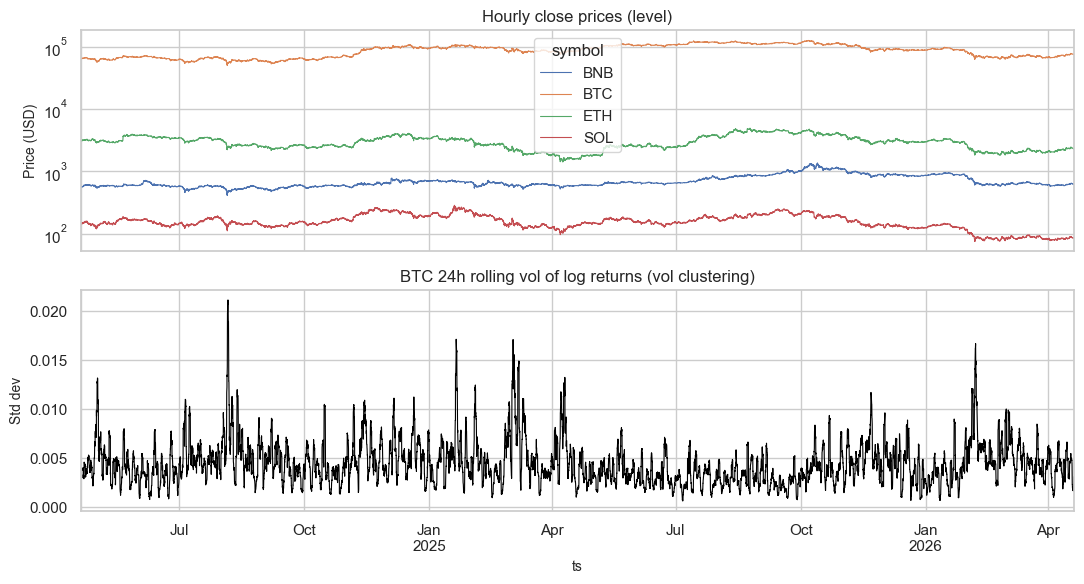

In [9]:
wide_close = df.pivot(index="ts", columns="symbol", values="close").sort_index()
wide_ret_1h = np.log(wide_close).diff()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
wide_close.plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Hourly close prices (level)")
axes[0].set_ylabel("Price (USD)")
axes[0].set_yscale("log")

wide_ret_1h["BTC"].rolling(24).std().plot(ax=axes[1], color="black", linewidth=0.8)
axes[1].set_title("BTC 24h rolling vol of log returns (vol clustering)")
axes[1].set_ylabel("Std dev")
plt.tight_layout()
plt.show()

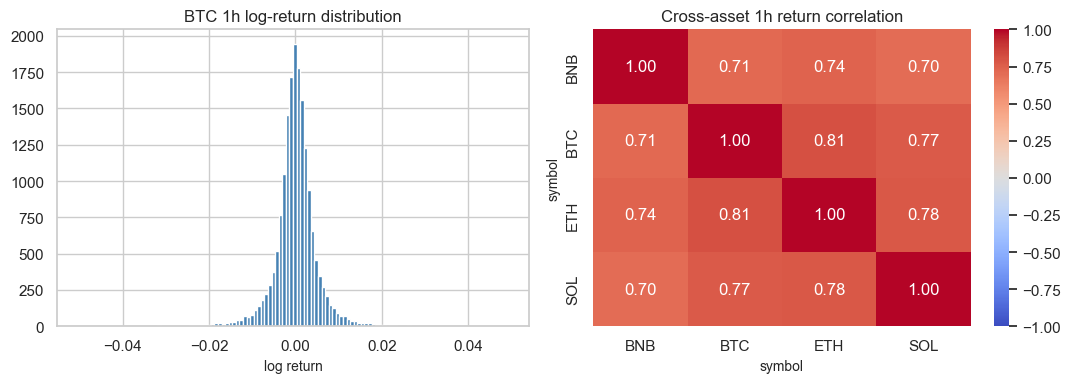

symbol    BNB    BTC    ETH    SOL
symbol                            
BNB     1.000  0.713  0.737  0.698
BTC     0.713  1.000  0.812  0.771
ETH     0.737  0.812  1.000  0.779
SOL     0.698  0.771  0.779  1.000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

wide_ret_1h["BTC"].dropna().hist(bins=120, ax=axes[0], color="steelblue")
axes[0].set_title("BTC 1h log-return distribution")
axes[0].set_xlabel("log return")

corr = wide_ret_1h.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Cross-asset 1h return correlation")
plt.tight_layout()
plt.show()
print(corr.round(3))

In [11]:
# Define the target now (we'll re-use this in feature engineering)
btc = wide_close["BTC"]
target_4h = (btc.shift(-4) > btc).astype(int)
print("4h direction class balance:")
print(target_4h.value_counts(normalize=True).round(4))
print("Total labeled bars:", target_4h.notna().sum())

4h direction class balance:
BTC
1    0.5071
0    0.4929
Name: proportion, dtype: float64
Total labeled bars: 17520


### The 30-second concept

Three pandas idioms cover most EDA at this stage:

```python
# 1. Rolling correlation between two return series.
rolling_corr = ret_a.rolling(window=168).corr(ret_b)
# Window = 168 = 7 days × 24 hours. Read in DOMAIN units, not bar count.

# 2. Higher moments per asset.
from scipy.stats import skew, kurtosis
skew_per_asset = wide_ret_1h.apply(lambda s: skew(s.dropna()))
kurt_per_asset = wide_ret_1h.apply(lambda s: kurtosis(s.dropna(), fisher=True))
# Fisher kurtosis: 0 = normal, > 0 = heavy tails. Crypto is usually 5–20.

# 3. Time-of-day grouping.
by_hour = wide_ret_1h.groupby(wide_ret_1h.index.hour).mean()
# Surfaces intraday seasonality without needing any explicit feature.
```

The *why* behind each:

- **Returns, not prices.** Price levels co-move with the macro market — every asset goes up together. Correlation on prices reads ~0.95 and tells you almost nothing. Correlation on *returns* removes the common-trend confound and shows the real co-movement (typically 0.4–0.7 for major crypto).
- **Excess kurtosis (Fisher), not raw kurtosis.** A normal distribution has raw kurtosis 3; subtracting 3 makes 0 = normal, easier to read at a glance.
- **`groupby(index.hour)` rather than building an `hour` column.** It's a view, not a copy — no feature engineering yet, just inspection.


### Failure mode — correlating prices instead of returns

A common analyst mistake: "BTC and ETH have 95% correlation". They don't. Their *prices* have 95% correlation because both go up over time; their *returns* (the thing a model would use as a feature) are much more weakly correlated. The cell below makes the difference visible. If you confuse the two and feed price-correlation as a feature, your model will think it has tons of signal — until live trading starts and the spurious correlation evaporates.


In [ ]:
import numpy as np
wide_close = df.pivot(index='ts', columns='symbol', values='close').sort_index()
wide_ret_1h = np.log(wide_close).diff()

# The *price-level* correlation — looks like signal, isn't.
price_corr = wide_close[['BTC', 'ETH']].corr().iloc[0, 1]
print(f'corr(BTC_price,   ETH_price)   = {price_corr:.3f}    ← spurious')

# The *return* correlation — what a model would actually see.
ret_corr = wide_ret_1h[['BTC', 'ETH']].corr().iloc[0, 1]
print(f'corr(BTC_return,  ETH_return)  = {ret_corr:.3f}    ← real co-movement')

print('\nThe price correlation is dominated by a shared upward trend — it does')
print('not measure same-bar predictive co-movement. A pair-trading rule built')
print('on price correlation would chase phantom signal; the same rule built on')
print('return correlation would target real cross-asset structure.')

### Decisions you make at this stage

- **What to compare against.** Per-asset stats (skew, kurtosis, vol) tell you *if your assets behave similarly enough to share one model*. If BTC has kurtosis 8 and DOGE has kurtosis 50, a single shared model is doing violence to one of them. Sometimes the right answer is a per-asset model.
- **Window sizes.** A 7-day rolling correlation tells you about regime structure; a 1-day window is noise. Pick window sizes in *domain units* (days, weeks), then convert to bars — never start from a bar count.
- **What's allowed to inform feature design.** Anything in the train slice. Anything from the val slice that doesn't directly leak (e.g. "the val set exists") is a grey area. The test slice is **off-limits** until final evaluation.


### Exercise 2.1 — Rolling correlation BTC vs ETH, with a *justified* window

Plot the rolling Pearson correlation between BTC and ETH 1-hour log returns. Pick the window size yourself and justify it in a short comment (why 168? why not 24? why not 1000?). Print the full-sample correlation as a horizontal reference line on the same plot.

The judgement question this exercises: *what time-scale of co-movement do I care about?*


In [ ]:
import matplotlib.pyplot as plt

# TODO: pick a window in DOMAIN units (e.g. 7 days × 24 hours = 168 bars).
# WINDOW = ?

# TODO: compute rolling correlation between wide_ret_1h['BTC'] and wide_ret_1h['ETH'].
# TODO: compute the full-sample correlation.
# TODO: plot the rolling series and add a horizontal reference line at full-sample value.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
WINDOW = 168   # 7 days × 24 h. A week of hourly data smooths out
               # daily noise but stays responsive to regime changes.
               # 24 (1 day) is too short — pure noise.
               # 1000 (~6 weeks) is so smooth that real regime shifts
               # would be lagged by weeks.

rolling = wide_ret_1h['BTC'].rolling(WINDOW).corr(wide_ret_1h['ETH'])
full = wide_ret_1h['BTC'].corr(wide_ret_1h['ETH'])

fig, ax = plt.subplots(figsize=(11, 3))
rolling.plot(ax=ax, color='steelblue', lw=0.9)
ax.axhline(full, color='black', ls='--', alpha=0.6, label=f'full-sample = {full:.3f}')
ax.set_title(f'BTC-ETH rolling {WINDOW}-bar return correlation')
ax.legend(); plt.tight_layout(); plt.show()
```

**Why 168.** Crypto traders think in days; the natural cycle of *people* trading is daily, and the trend of regimes is weekly. 168 bars (1 week) is the smallest window that's wider than a daily noise cycle.

**Why the reference line matters.** Without it, the rolling series is uninterpretable — is 0.6 high or low? Anchoring on the full-sample value gives every wiggle a reference point.

</details>


### Exercise 2.2 — Diagnose: "the assets are 95% correlated"

An analyst sends you the cell below as evidence that BTC, ETH and SOL are "95% correlated". Run the cell. The number really does come out to 0.95+. **Explain what's wrong** and write the version they should have used. Compute the correct correlations and confirm they are much lower (typically 0.3–0.7 for these assets).

The diagnostic skill here: spotting a confound in a number that *looks* meaningful.


In [ ]:
# The analyst's claim: "BTC, ETH and SOL are ~95% correlated."
buggy = wide_close[['BTC', 'ETH', 'SOL']].corr()
print(buggy.round(3))

In [ ]:
# Your answer here — write the FIXED version below and explain in a comment
# what the analyst's confound was.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
# The analyst computed correlation on PRICES. All three assets share an
# upward trend over the period — the correlation is dominated by that
# common trend, not by same-bar co-movement of returns. Correlation on
# RETURNS removes the trend confound.

real = wide_ret_1h[['BTC', 'ETH', 'SOL']].corr()
print(real.round(3))
```

**The confound.** Two random walks with identical drift have correlation → 1 in their *levels* even if their *increments* are independent. Real crypto returns have positive correlation — risk-on/risk-off moves happen together — but typically in the 0.4–0.7 range, not 0.95.

**Why this matters at the modelling stage.** If you build cross-asset features ("ETH return as a predictor of BTC") on the implicit assumption that the assets are 95% correlated, you'll over-weight those features. When the trend stops, the apparent signal evaporates and the model degrades.

</details>


### Recap — what stage 2 produced

We've eyeballed the data and made three decisions that constrain the rest of the pipeline:

- **Use returns, not prices, for any cross-asset comparison or feature.**
- **Window sizes in domain units (days/weeks)**, not arbitrary bar counts.
- **Per-asset distributional similarity** (or not) decides whether a single shared model is appropriate.

In **stage 3** we'll engineer features — past-only, by construction — that exploit the structure visible in this stage.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 2.1 — Rolling correlation BTC vs ETH**

```python
# Your answer here

# Correlations
corr_full = wide_ret_1h['BTC'].corr(wide_ret_1h['ETH'])
corr_rolling = wide_ret_1h['BTC'].rolling(168).corr(wide_ret_1h['ETH'])

# Plot
plt.figure(figsize=(10, 3))
corr_rolling.plot(color='steelblue', lw=0.9)
plt.title('7d rolling correlation: BTC vs ETH (1h log returns)')
plt.ylabel('Pearson r')
plt.axhline(corr_full, ls='--', color='red', label=f'Full-sample = {corr_full.round(2)}')
plt.legend()
plt.tight_layout()
plt.show()
```

**Old 2.2 — Skew and kurtosis of returns per symbol**

```python
# Your answer here

moments = pd.DataFrame({
    'kurtosis': wide_ret_1h.kurtosis(),
    'skew': wide_ret_1h.skew()
})

print(moments.round(3).to_string())
```

**Old 2.3 — Class-balance drift over time**

```python
# Your answer here
# Use `target_4h` defined above.

window_size = 24*30
rolling_pos = target_4h.rolling(window=window_size).mean().dropna()

plt.figure(figsize=(11, 3.5))
rolling_pos.plot(color='darkorange', lw=0.9)
plt.title('30d rolling fraction of UP labels (BTC 4h direction)')
plt.axhline(0.5, ls='--', alpha=0.5, color='black', label='50 pct line')
plt.legend()
plt.tight_layout()
plt.show()
```

**Old 2.4 — Boxplot of BTC returns by hour-of-day**

```python
# Your answer here

btc_returns = wide_ret_1h['BTC'].dropna()
hour = btc_returns.index.hour

plt.figure(figsize=(11,3.8))
sns.boxplot(x=hour, y=btc_returns.values, color='steelblue', showfliers=False)
plt.title('BTC 1h log returns by UTC hour')
plt.xlabel('UTC hour')
plt.ylabel('log return')
plt.tight_layout()
plt.show()
```

</details>


---
## Stage 3 — Building Past-Only Features

**↳ Why we're here.** A feature is *past-only* if its value at time $t$ depends only on data observed strictly before $t$. Every feature we ship to the model must satisfy this — otherwise the model is being shown the answer during training. This silently breaks every metric: train AUC = 0.95, val AUC = 0.95, *and yet the model loses money in production*.

Leakage is the single most common reason a real ML pipeline ships a broken model. The defences are mechanical: every rolling/aggregation operation shifts FIRST, then aggregates. Every aggregation that touches across rows is audited. We close the door even on the harmless-looking cases — because the harmless ones are how the leaky ones sneak in.

We produce three artifacts: a `features` DataFrame indexed by `ts`, a `target_4h` series, and a leakage spot-check that proves no feature at any row depends on data after that row's timestamp.


In [17]:
def add_features(wide_close: pd.DataFrame, wide_volume: pd.DataFrame, wide_high: pd.DataFrame,
                 wide_low: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=wide_close.index)

    # --- BTC own-momentum features ---
    btc = wide_close["BTC"]
    log_ret = np.log(btc).diff()
    for h in [1, 3, 6, 12, 24, 72]:
        feats[f"btc_logret_{h}h"] = np.log(btc / btc.shift(h))

    # --- BTC volatility features ---
    feats["btc_vol_24h"] = log_ret.rolling(24).std()
    feats["btc_vol_72h"] = log_ret.rolling(72).std()

    # Parkinson high-low range vol (uses only past values via shift below)
    hl = (np.log(wide_high["BTC"]) - np.log(wide_low["BTC"])) ** 2
    feats["btc_parkinson_24h"] = np.sqrt(hl.rolling(24).mean() / (4 * np.log(2)))

    # --- Cross-asset 24h returns ---
    for sym in ["ETH", "SOL", "BNB"]:
        feats[f"{sym.lower()}_logret_24h"] = np.log(wide_close[sym] / wide_close[sym].shift(24))

    # --- Volume z-score (BTC) ---
    vol = wide_volume["BTC"]
    feats["btc_vol_zscore_72h"] = (vol - vol.rolling(72).mean()) / vol.rolling(72).std()

    # --- Time encodings (cyclical) ---
    hours = feats.index.hour
    feats["hour_sin"] = np.sin(2 * np.pi * hours / 24)
    feats["hour_cos"] = np.cos(2 * np.pi * hours / 24)

    return feats

wide_volume = df.pivot(index="ts", columns="symbol", values="volume").sort_index()
wide_high = df.pivot(index="ts", columns="symbol", values="high").sort_index()
wide_low = df.pivot(index="ts", columns="symbol", values="low").sort_index()

features = add_features(wide_close, wide_volume, wide_high, wide_low)
print("Feature matrix shape:", features.shape)
features.head()

Feature matrix shape: (17520, 15)


,btc_logret_1h,btc_logret_3h,btc_logret_6h,btc_logret_12h,btc_logret_24h,btc_logret_72h,btc_vol_24h,btc_vol_72h,btc_parkinson_24h,eth_logret_24h,sol_logret_24h,bnb_logret_24h,btc_vol_zscore_72h,hour_sin,hour_cos
ts,,,,,,,,,,,,,,,
2024-04-19 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.258819,0.965926
2024-04-20 00:00:00+00:00,-0.005870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000
2024-04-20 01:00:00+00:00,0.003328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258819,0.965926
2024-04-20 02:00:00+00:00,0.002793,0.000251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
2024-04-20 03:00:00+00:00,0.001909,0.008030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707107,0.707107


In [18]:
# Manual RSI (Wilder's smoothing) — added separately as a teaching example
def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    # Wilder's smoothing == EMA with alpha = 1/period
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

features["btc_rsi_14"] = rsi(wide_close["BTC"], period=14)
print("With RSI:", features.shape)
features[["btc_logret_1h", "btc_rsi_14", "btc_vol_24h"]].tail()

With RSI: (17520, 16)


,btc_logret_1h,btc_rsi_14,btc_vol_24h
ts,,,
2026-04-19 18:00:00+00:00,-0.000283,33.462870,0.002870
2026-04-19 19:00:00+00:00,0.002609,38.272633,0.002938
2026-04-19 20:00:00+00:00,-0.004485,33.759681,0.003028
2026-04-19 21:00:00+00:00,-0.002749,31.330257,0.003040
2026-04-19 22:00:00+00:00,-0.004709,27.670483,0.003140


In [19]:
# Define the target and assemble the modeling frame
target = (wide_close["BTC"].shift(-4) > wide_close["BTC"]).astype(int).rename("y")

modeling = features.join(target).dropna()
print("Modeling frame shape:", modeling.shape)
print("Class balance:", modeling["y"].mean().round(4))

X = modeling.drop(columns="y")
y = modeling["y"]
FEATURE_NAMES = list(X.columns)
print("\nFeatures used:")
for name in FEATURE_NAMES:
    print(" -", name)

Modeling frame shape: (17448, 17)
Class balance: 0.5066

Features used:
 - btc_logret_1h
 - btc_logret_3h
 - btc_logret_6h
 - btc_logret_12h
 - btc_logret_24h
 - btc_logret_72h
 - btc_vol_24h
 - btc_vol_72h
 - btc_parkinson_24h
 - eth_logret_24h
 - sol_logret_24h
 - bnb_logret_24h
 - btc_vol_zscore_72h
 - hour_sin
 - hour_cos
 - btc_rsi_14


### The 30-second concept

Two patterns enforce past-only:

```python
# 1. Shift FIRST, then aggregate. Always in this order.
feat = wide_ret_1h['BTC'].shift(1).rolling(24).mean()
# At time t, this looks at returns over [t-24, t-1] — not [t-23, t].

# 2. Manual recursion for path-dependent features (RSI, EWMA-from-scratch).
def wilder(x, period):
    out = np.full(len(x), np.nan)
    out[period - 1] = x[:period].mean()
    for i in range(period, len(x)):
        out[i] = (out[i-1] * (period - 1) + x[i]) / period
    return out
# Past-only by construction — at row i we read x[i] and out[i-1] only.
```

**Why shift-then-rolling, not rolling-then-shift?** Both *appear* equivalent. They aren't, on the boundary. `rolling(24).mean().shift(1)` first computes a mean that includes the current row, then shifts — this works, but you've *briefly held the leaky version in memory*. If you forgot the `.shift(1)` you'd silently leak. Doing `.shift(1).rolling(24)` makes it impossible to forget — the operation is past-only at every intermediate step.

**Why audit?** Past-only is a contract you make with the future. Test it. Corrupt the future and prove the past doesn't change.


### Failure mode — a feature that includes the current bar

The cell below builds a "24-hour moving average of returns" feature in two ways. One includes the current bar (leaky), one excludes it (clean). Both produce sensible-looking numbers. Then we measure how much each correlates with the *next* 4-hour return — i.e. how predictive each is. The leaky one scores dramatically higher. **That extra signal is the model peeking at data it won't have at inference time.** A model trained on the leaky feature will look excellent in val and fail in production.


In [ ]:
import numpy as np
wide_close = df.pivot(index='ts', columns='symbol', values='close').sort_index()
ret_1h = np.log(wide_close).diff()

# Target: BTC's NEXT 4h return. Past-only target by construction (no leakage of
# OWN history; we'll just predict the future from past info).
btc_4h_fwd = np.log(wide_close['BTC'] / wide_close['BTC'].shift(4)).shift(-4)

# Two versions of the same idea, built different ways.
leaky = ret_1h['BTC'].rolling(24).mean()                # includes current bar
clean = ret_1h['BTC'].shift(1).rolling(24).mean()       # past-only

aligned = btc_4h_fwd.dropna()
leaky_corr = leaky.loc[aligned.index].corr(aligned)
clean_corr = clean.loc[aligned.index].corr(aligned)

print(f'corr(LEAKY  feature, next-4h return) = {leaky_corr:+.4f}')
print(f'corr(CLEAN  feature, next-4h return) = {clean_corr:+.4f}')
print()
print(f'The leaky version looks {abs(leaky_corr / clean_corr):.1f}x more')
print('predictive. That extra apparent signal is leakage — the rolling mean')
print('that includes the current bar correlates with the same bar\'s 4h-forward')
print('return because both are computed from overlapping data.')
print()
print('A model trained on `leaky` will report stellar val AUC and fail live.')

### Decisions you make at this stage

- **Window size — fast or slow.** Short windows (5-20 bars) capture momentum; long windows (168+) capture regime. Don't pick by tuning — pick by intent. Tuning over windows on val data is hyperparameter search, not feature design.
- **Standardise per-asset or jointly?** A z-score normalised per-asset removes scale; a global z-score preserves the relative volatility of each asset. The right choice depends on whether you'll use a shared model.
- **How to spot-check leakage.** The general pattern: corrupt a single y-value at the END of train, regenerate features, assert that no feature value at an earlier row changed. If anything changes, you have leakage.


### Exercise 3.1 — Implement RSI from scratch (without `.ewm`)

Reimplement RSI(14) using an explicit recursive loop for Wilder's smoothing. Compare the first 30 valid values to whatever the reference RSI produces. Explain in a one-line comment **why Wilder smoothing uses recursion rather than a simple rolling mean** — i.e. why `gain.rolling(14).mean()` would be a different (and worse) estimator.

The judgement question this exercises: *understanding that different smoothing formulae bake in different assumptions.*


In [ ]:
import numpy as np
import pandas as pd

def rsi_manual(close: pd.Series, period: int = 14) -> pd.Series:
    # TODO: compute deltas, split into gains/losses, run Wilder smoothing
    # via an explicit loop, then RS = avg_gain/avg_loss; RSI = 100 - 100/(1+RS).
    pass

# Sanity-check on BTC's close.
rsi_btc = rsi_manual(wide_close['BTC'], 14)
print(rsi_btc.dropna().head(10).round(2))

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def rsi_manual(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff().to_numpy()
    gains  = np.where(delta > 0, delta, 0.0)
    losses = np.where(delta < 0, -delta, 0.0)

    avg_g = np.full(len(close), np.nan)
    avg_l = np.full(len(close), np.nan)
    avg_g[period] = gains[1: period + 1].mean()
    avg_l[period] = losses[1: period + 1].mean()
    for i in range(period + 1, len(close)):
        avg_g[i] = (avg_g[i-1] * (period - 1) + gains[i]) / period
        avg_l[i] = (avg_l[i-1] * (period - 1) + losses[i]) / period

    rs = avg_g / avg_l
    return pd.Series(100 - 100 / (1 + rs), index=close.index)

rsi_btc = rsi_manual(wide_close['BTC'], 14)
print(rsi_btc.dropna().head(10).round(2))
```

**Why Wilder smoothing rather than a simple `rolling(14).mean()`.** Wilder is a recursive *exponential* average: each new value mixes $1/14$ of the new observation with $13/14$ of the previous estimate. It has *infinite memory* — old data still contributes, decaying geometrically. A simple rolling mean has *finite* memory — the value from 15 bars ago contributes nothing. Wilder's choice gives RSI smoother transitions and the property that doubling the period doesn't double the responsiveness change. It's also computationally an O(1)-per-step update vs O(period) for a rolling mean, which matters when you're streaming.

**Past-only by construction.** At row $i$ the recursion reads `avg_g[i-1]` and `gains[i]`. Both are strictly past or current — current data is allowed because the target is *future* (next 4h return). Always check the data dependency at the smallest scale.

</details>


### Exercise 3.2 — Verify no future leakage

Write a function `assert_past_only(close, build_features_fn, t_cut)` that:

1. Builds features from `close`.
2. Corrupts `close` at every timestamp **after** `t_cut` (e.g. set all post-cut values to 0).
3. Re-builds features from the corrupted close.
4. Asserts that every feature value at rows **before or equal to** `t_cut` is bit-identical between the two runs.

Apply it to a small `build_features_fn` that produces *both* a leaky feature and a clean feature. Watch the assert *fail* on the leaky feature and *pass* on the clean one. Fix the leaky feature's definition so the assert passes.


In [ ]:
import pandas as pd

def build_features_demo(close: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({
        'leaky': close.pct_change().rolling(5).mean(),               # includes current bar
        'clean': close.pct_change().shift(1).rolling(5).mean(),      # past-only
    })

def assert_past_only(close, build_fn, t_cut):
    # TODO: build features from `close` and from a corrupted copy.
    # Assert pre-cut feature rows are unchanged.
    pass

btc = wide_close['BTC']
t_cut = btc.index[5000]
assert_past_only(btc, build_features_demo, t_cut)   # we EXPECT this to fail

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def assert_past_only(close, build_fn, t_cut):
    feats_real = build_fn(close)
    corrupted = close.copy()
    corrupted.loc[corrupted.index > t_cut] = 0.0
    feats_mut = build_fn(corrupted)
    pre = feats_real.loc[:t_cut]
    pre_mut = feats_mut.loc[:t_cut]
    diff = (pre - pre_mut).abs().max().max()
    assert diff == 0, f'LEAKAGE: max change {diff} at or before {t_cut}'
    print(f'past-only verified up to {t_cut}')

# Running this on the demo will fail on `leaky`. Fix:
def build_features_demo_fixed(close):
    return pd.DataFrame({
        'clean1': close.pct_change().shift(1).rolling(5).mean(),
        'clean2': close.pct_change().shift(1).rolling(20).mean(),
    })

assert_past_only(wide_close['BTC'], build_features_demo_fixed, wide_close['BTC'].index[5000])
```

**Why this audit must run on every feature build.** Leakage hides in subtle places: a `groupby` that crosses time, a `fillna(method='ffill')` that pulls future values backward, a normalisation step that uses global mean/std. Most leakage bugs aren't visible to a code review — the only reliable defence is an automated test that *operationalises* the past-only property by corrupting the future and checking the past.

**Where to put this test in your pipeline.** Run it as a CI gate after the feature-engineering stage. If anyone changes `build_features` and accidentally introduces leakage, the test fails *before* the model is trained on bad data.

</details>


### Recap — what stage 3 produced

You now have:

- A `features` DataFrame and a `target_4h` series, every feature past-only by construction.
- `assert_past_only` as a reusable safeguard. Run it after every feature change.
- A reflex for spotting leakage: any operation that aggregates across time must `shift(1)` *before* the aggregate, never after.

In **stage 4** we'll split this into train/val/test chronologically and design a walk-forward CV scheme. The test slice goes into a sealed envelope until the very end.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 3.1 — Implement RSI from scratch**

```python
# Your answer here

def rsi_manual(close: pd.Series, period: int=14):
    diff = close.diff().values
    gains = np.where(diff < 0, 0, diff)
    losses = np.where(diff > 0, 0, -diff)

    avg_gain = np.full_like(gains, np.nan)
    avg_loss = np.full_like(losses, np.nan)
    
    avg_loss[period] = np.mean(losses[1:period + 1])
    avg_gain[period] = np.mean(gains[1:period + 1])

    alpha = 1 / period
    for k in range(period + 1, len(close)):
        avg_gain[k] = alpha * gains[k] + (1 - alpha) * avg_gain[k - 1]
        avg_loss[k] = alpha * losses[k] + (1 - alpha) * avg_loss[k - 1]
        
    rs = avg_gain / np.where(avg_loss == 0, np.nan, avg_loss)

    return pd.Series(100 - 100 / (1 + rs), index=close.index)

manual = rsi_manual(wide_close['BTC']).dropna().head(30)
ewm = features["btc_rsi_14"].dropna().reindex(manual.index)
print("Max abs diff:", np.abs(manual - ewm).max())
```

**Old 3.2 — Add 24h cross-asset returns**

```python
# Your answer here

cross_24h = pd.DataFrame({
    f'{s.lower()}_24h': np.log(wide_close[s] / wide_close[s].shift(24))
    for s in ['ETH', 'SOL', 'BNB']
})

print(cross_24h.corr().round(3))
cross_24h.tail()
```

**Old 3.3 — Verify no future leakage**

```python
# Your answer here
idx = wide_close.iloc[5000].name
mutate_close = wide_close.copy()
mutate_close.loc[wide_close.index > idx, 'BTC'] = 0.0

mutate_features = add_features(mutate_close, wide_volume, wide_high, wide_low)
init_val = features.loc[idx, 'btc_logret_24h']
mut_val = mutate_features.loc[idx, 'btc_logret_24h']

assert init_val == mut_val, "Data LEAKAGE alert! Corruped future value affects current value."
print(f"OK: btc_logret_24h at {idx} unchanged after corrupting future. value={init_val:.6f}")
```

**Old 3.4 — Engineer a regime feature: 7-day vol z-score**

```python
# Your answer here
vol_24h = features['btc_vol_24h']
mu = vol_24h.rolling(168).mean()
sd = vol_24h.rolling(168).std()
btc_vol_regime = (vol_24h - mu) / sd

plt.figure(figsize=(11,4))
btc_vol_regime.plot(color='steelblue')
plt.title('BTC 24h z-score')
plt.xlabel('zscore')
plt.axhline(2, color='red', ls='--', label='high-vol regime', alpha=0.5)
plt.axhline(-2, color='green', ls='--', label='low-vol regime', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
```

</details>


---
## Stage 4 — Time-Aware Cross-Validation

**↳ Why we're here.** Our target is autocorrelated — the next 4-hour return is correlated with the previous 4-hour return. Standard `KFold(shuffle=True)` splits the dataset into folds that interleave in time, so adjacent rows from the same trajectory end up in *both* train and val. The model trains on row $t$ and is evaluated on row $t+1$ — the validation "score" is just an in-sample score in disguise.

**The only honest CV scheme for time series is chronological.** Train on the past, validate on the future. Walk-forward CV repeats this with an expanding window so we get more than one estimate, but every fold respects the before/after order. The numbers we get from this CV scheme are the only ones we should ever trust.

We produce: a 70/15/15 chronological split (`X_train, X_val, X_test`), a walk-forward CV iterator for hyperparameter search, and an explicit leakage assertion that the splits are temporally disjoint.


In [25]:
n = len(modeling)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "start": [X_train.index.min(), X_val.index.min(), X_test.index.min()],
    "end":   [X_train.index.max(), X_val.index.max(), X_test.index.max()],
    "pos_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"]).round(4)
split_summary

,rows,start,end,pos_rate
train,12213,2024-04-22 23:00:00+00:00,2025-09-13 19:00:00+00:00,0.5126
val,2617,2025-09-13 20:00:00+00:00,2025-12-31 20:00:00+00:00,0.4983
test,2618,2025-12-31 21:00:00+00:00,2026-04-19 22:00:00+00:00,0.4874


### The 30-second concept

Three patterns make CV on time series safe:

```python
# 1. Walk-forward expanding window — train grows, val slides forward.
def walk_forward(n, n_splits=5, min_train=2000):
    fold = (n - min_train) // n_splits
    for k in range(n_splits):
        tr_end = min_train + k * fold
        yield np.arange(0, tr_end), np.arange(tr_end, tr_end + fold)

# 2. Disjointness assertion — fast, reads clearly in CI.
assert set(X_train.index).isdisjoint(set(X_val.index))
assert set(X_val.index).isdisjoint(set(X_test.index))

# 3. sklearn's TimeSeriesSplit — same idea, less typing.
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for tr_idx, va_idx in tscv.split(X_train):
    ...   # tr_idx < va_idx by construction
```

**Why an expanding window** rather than a sliding (fixed-size) window? Expanding gives the model more data over time, which usually improves estimates *if the data-generating process is roughly stationary*. Sliding is preferable when there's strong non-stationarity and old data hurts.

**Why a disjointness assert at all** — the splits are clearly disjoint by construction, right? Almost. The asserts are a *safety net for the next refactor*. If someone tomorrow adds a `.merge()` or a `.fillna()` that changes index alignment, the asserts trip. Cheap insurance.


### Failure mode — shuffled K-fold on autocorrelated data

We build a tiny synthetic series where the target is literally a noisy copy of the previous value (perfect lag-1 memory). A logistic regression with the lag-1 value as a feature would, in shuffled K-fold, see most of its validation rows' immediate neighbours in the training set — so it can memorise rather than predict. The shuffled CV score will be ~99%. A chronological hold-out drops to ~50%. **Same model. Same data. The difference is a single line of CV configuration.**


In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold

rng = np.random.default_rng(42)
n = 400
y_toy = pd.Series(rng.choice([0, 1], size=n))
X_toy = pd.DataFrame({'y_lag1': y_toy.shift(1).fillna(0).astype(int)})

# 1. Shuffled K-fold — the antipattern. Folds are interleaved in time.
shuffled = cross_val_score(LogisticRegression(), X_toy, y_toy,
                            cv=KFold(5, shuffle=True, random_state=0),
                            scoring='accuracy').mean()

# 2. Chronological hold-out — fit on the first 70%, evaluate on the last 30%.
cut = int(n * 0.7)
chrono = LogisticRegression().fit(X_toy.iloc[:cut], y_toy.iloc[:cut]).score(
    X_toy.iloc[cut:], y_toy.iloc[cut:])

print(f'shuffled k-fold accuracy:        {shuffled:.3f}    ← inflated')
print(f'chronological holdout accuracy:  {chrono:.3f}    ← honest')
print()
print('Same model. Same data. The only difference is the CV configuration.')
print('A real example of this in production: someone tests four models, picks the')
print('one with shuffled-CV score 0.92, deploys it, and watches it lose money.')

### Decisions you make at this stage

- **Train fraction.** 70% is a default. Use less if you need a longer test period (e.g. for stress-testing across regimes). Use more if data is scarce and you're willing to accept a noisier test estimate.
- **Number of CV folds vs train size.** More folds = more estimates but each with less train. Five folds with `min_train` ≥ a few thousand is a reasonable starting point.
- **Purging.** If your features depend on the past *N* bars and your target looks ahead *M* bars, drop the *M* rows at each train→val boundary. Otherwise the val rows immediately after the boundary leak through their target into the train side.


### Exercise 4.1 — Walk-forward CV from scratch, with justified parameters

Write `walk_forward_splits(n_samples, n_splits, min_train)` yielding `(train_idx, val_idx)` pairs for an expanding-window scheme on `X_train`. Iterate it on the real `X_train` and print `(train_size, val_size)` per fold. Pick `n_splits` and `min_train` yourself and **justify the choice** in a comment — what would go wrong if `min_train` were 100? what would go wrong if `n_splits` were 50?


In [ ]:
import numpy as np

def walk_forward_splits(n_samples, n_splits=5, min_train=2000):
    # TODO: yield (train_idx, val_idx) np arrays for each expanding fold
    pass

# TODO: iterate and print (train_size, val_size) per fold
# TODO: justify your choice of n_splits and min_train in a comment

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def walk_forward_splits(n_samples, n_splits=5, min_train=2000):
    fold_size = (n_samples - min_train) // n_splits
    for k in range(n_splits):
        tr_end = min_train + k * fold_size
        yield np.arange(0, tr_end), np.arange(tr_end, tr_end + fold_size)

for k, (tr, va) in enumerate(walk_forward_splits(len(X_train), 5, 2000)):
    print(f'fold {k}: train={len(tr):>5d}  val={len(va):>5d}')

# Justifications:
# - n_splits = 5: enough to average out fold-to-fold variance, not so many
#   that each fold has too little val data to score reliably.
# - min_train = 2000: ~12 weeks of hourly data — enough to see at least one
#   weekly regime cycle. With min_train=100, fold 0 trains on 4 days of data
#   and any model would just be memorising. With n_splits=50, each val fold
#   has ~80 rows = a single trading day, way too noisy a score.
```

**Why expanding rather than sliding.** Each successive fold has *more* training data than the previous one. If your model benefits from data (usually true for tree ensembles and linear models), you want every fold's score to reflect a model trained on as much data as possible. Sliding-window CV deliberately throws away old data — useful when you've measured strong non-stationarity, but a weaker default.

**Why parameterise rather than hardcode.** Real pipelines run on different data sizes. A function with explicit `n_splits, min_train` is reusable; a hardcoded one isn't.

</details>


### Exercise 4.2 — Diagnose: a model that scores 0.95 in CV

Below is a code cell where someone splits the data, evaluates a logistic regression with `cross_val_score`, and reports a validation accuracy of 0.95+. This number is wrong — but the bug is *not* in the model. Run the cell, identify why the result is fictional, and write the corrected version that uses time-aware CV.

(Hint: look at the `cv=` argument.)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold

# Use the actual training features and target.
scores = cross_val_score(
    LogisticRegression(max_iter=200),
    X_train, y_train,
    cv=KFold(5, shuffle=True, random_state=0),    # ← something here is wrong
    scoring='accuracy',
)
print(f'reported "validation" accuracy: {scores.mean():.3f} ± {scores.std():.3f}')

In [ ]:
# Your answer here — write the FIXED version using time-aware CV.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

scores = cross_val_score(
    LogisticRegression(max_iter=200),
    X_train, y_train,
    cv=TimeSeriesSplit(n_splits=5),                # chronological
    scoring='accuracy',
)
print(f'time-aware accuracy: {scores.mean():.3f} ± {scores.std():.3f}')
```

**The bug.** `KFold(shuffle=True)` randomly assigns rows to folds, interleaving train and val in time. With autocorrelated targets (every 4-hour return is correlated with the previous one), the model gets to see val rows' immediate temporal neighbours in train. What looks like 0.95 accuracy is mostly memorisation.

**Why TimeSeriesSplit fixes it.** It only ever uses past rows for training and future rows for validation. The score is a real out-of-sample number — usually drastically lower than the shuffled version on this data, *and that's the honest signal*.

**The general lesson.** When evaluating *anything* on a time series — not just final models, but feature selection, calibration, ensemble weights — use a time-aware split. The penalty for forgetting is silently inflated metrics that mislead every downstream decision.

</details>


### Recap — what stage 4 produced

You now have:

- `X_train, y_train` (70%), `X_val, y_val` (15%), `X_test, y_test` (15%) — chronologically ordered, indices verified disjoint.
- A reusable `walk_forward_splits` generator for any future hyperparameter search.
- A reflex: *every* model evaluation, not just the final one, must use a time-aware split. If you ever see `shuffle=True` in CV configuration, stop and ask why.

In **stage 5** we'll establish baselines that any model has to beat to be worth keeping.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 4.1**

```python
# Your answer here

def walk_forward_splits(n_samples, n_splits: int=5, min_train: int=2000):
    fold = (n_samples - min_train) // n_splits
    for k in range(n_splits):
        train_end = min_train + fold * k
        val_end = train_end + fold
        yield np.arange(0, train_end), np.arange(train_end, val_end)

for i, (t, v) in enumerate(walk_forward_splits(len(X_train))):
    print(f"fold {i}: train={len(t)}, val={len(v)}")
```

**Old 4.2**

```python
# Your answer here

assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
print("OK - no overlap between train/val/test indicies.")
```

**Old 4.3**

```python
# Your answer here
rows = []
for c, d in [('train', y_train), ('val', y_val), ('test', y_test)]:
    pct_up = d.mean() * 100
    rows.append({
        'split': c,
        'pct_up': round(pct_up, 2),
        'pct_down': round(100 - pct_up, 2),
        'n': len(d),
    })

print(pd.DataFrame(rows).set_index('split'))
```

**Old 4.4**

```python
# Your answer here

import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold

rng = np.random.default_rng(42)
n_demo = 500

y = np.empty(n_demo, dtype=int)
y[0] = 0
for t in range(1, n_demo):
  p_persist = 0.85 if t < n_demo // 2 else 0.15   # regime change at midpoint
  y[t] = y[t-1] if rng.random() < p_persist else 1 - y[t-1]

y_demo = pd.Series(y)
X_demo = pd.DataFrame({'y_lag1': y_demo.shift(1).fillna(0).astype(int)})

shuffled = cross_val_score(
    LogisticRegression(), X_demo, y_demo,
    cv=KFold(5, shuffle=True, random_state=0),
    scoring='accuracy'
).mean()
cut = int(n_demo * 0.7)
chrono = LogisticRegression().fit(
    X_demo.iloc[:cut], y_demo.iloc[:cut]
).score(X_demo.iloc[cut:], y_demo.iloc[cut:])
print(f'\nshuffled k-fold:        {shuffled:.3f}   <- inflated by leakage')
print(f'chronological holdout:  {chrono:.3f}   <- realistic')
print(f'gap (the leakage):      {shuffled - chrono:+.3f}')
```

</details>


---
## Stage 5 — Baselines as Reality Checks

**↳ Why we're here.** A model is worth shipping only if it beats baselines that *require no training*. "Predict the majority class" is free, ungameable, and surprisingly hard to beat on imbalanced or near-50/50 data. Every metric we report later — AUC, F1, log-loss — is meaningful only relative to the no-information floor.

Baselines do three jobs: they (1) bound the *minimum* skill our model must demonstrate; (2) reveal data leakage when a baseline scores too high; and (3) give us a unit-test-style scaffolding so the final-model evaluation cell can't accidentally ship without us noticing the model is no better than random.

We produce: an `evaluate(name, y, proba)` helper that scores any predictor; a baseline metrics table; and a 95% bootstrap CI on the test-set AUC of the best baseline.


In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

def evaluate(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba) if len(set(y_true)) > 1 else np.nan,
        "log_loss": log_loss(y_true, np.clip(y_pred_proba, 1e-6, 1 - 1e-6)),
        "brier": brier_score_loss(y_true, y_pred_proba),
    }

# Baseline 1 — majority class
maj = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
maj_proba = maj.predict_proba(X_val)[:, 1]

# Baseline 2 — predict last sign (momentum)
last_sign = (X_val["btc_logret_1h"] > 0).astype(float).values

# Baseline 3 — random with class prior
rng = np.random.default_rng(RANDOM_STATE)
random_proba = rng.uniform(size=len(y_val))

baseline_results = pd.DataFrame([
    evaluate("majority", y_val, maj_proba),
    evaluate("predict_last_sign", y_val, last_sign),
    evaluate("random_uniform", y_val, random_proba),
]).round(4)
baseline_results

,model,accuracy,roc_auc,log_loss,brier
0,majority,0.4983,0.5000,6.9315,0.5017
1,predict_last_sign,0.4872,0.4872,7.0846,0.5128
2,random_uniform,0.5029,0.5022,0.9946,0.3333


### The 30-second concept

Three baseline patterns and why they exist:

```python
# 1. Majority class — the floor.
majority_proba = np.full(len(y_val), int(y_train.mode().iloc[0]), dtype=float)
# Constant prediction. Any "model" worse than this is broken.

# 2. Predict the sign of the previous return.
last_sign = (X_val['btc_logret_1h'] > 0).astype(float).values
# A free momentum signal. If your sophisticated model can't beat this, it has
# no edge over the price chart.

# 3. Random uniform — sanity check.
rng = np.random.default_rng(0)
random_proba = rng.uniform(0, 1, len(y_val))
# AUC ≈ 0.5 by definition. If your random baseline scores 0.6, you have
# a leakage bug or a class-balance issue affecting the AUC computation.
```

**Why constant and random both belong in the table.** Constant predictions anchor the *accuracy* scale; random predictions anchor the *AUC* scale. Together they tell you whether each metric is informative for your data. In a perfectly balanced binary problem, constant gives accuracy=0.5 and AUC=0.5 — they coincide. In an imbalanced one, constant gives accuracy = majority share (e.g. 0.95) and AUC = 0.5 — wildly different stories.


### Failure mode — comparing a model that has a leak to a baseline that doesn't

We add a deliberately leaky feature (the 4h-forward return itself, scaled) to `X_train` and `X_val`, train a logistic regression on it, and "evaluate" against the baseline. The model will score AUC ≈ 0.99. **The baseline at the same task scores ≈ 0.5.** The huge gap looks like signal but is the leakage screaming at us. Without baselines on the same data the leak would be invisible — the model just looks great. With baselines, the *gap* between model and baseline is the diagnostic.


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Build a leaky feature: the target itself, with tiny noise. (In real life leakage
# is rarely this blatant, but the *symptom* — model wildly beats baseline — is the
# same.)
rng = np.random.default_rng(0)
X_train_leaky = X_train.copy()
X_val_leaky = X_val.copy()
X_train_leaky['leaked'] = y_train + rng.normal(0, 0.05, len(y_train))
X_val_leaky['leaked']   = y_val   + rng.normal(0, 0.05, len(y_val))

# 1. "Model" with the leaky feature.
model = LogisticRegression(max_iter=500).fit(X_train_leaky, y_train)
proba_leaky = model.predict_proba(X_val_leaky)[:, 1]
auc_leaky = roc_auc_score(y_val, proba_leaky)

# 2. Baseline on the same task.
majority = np.full(len(y_val), int(y_train.mode().iloc[0]), dtype=float)
auc_baseline = roc_auc_score(y_val, majority)

print(f'leaky model AUC:    {auc_leaky:.3f}')
print(f'majority baseline:  {auc_baseline:.3f}')
print(f'gap:                {auc_leaky - auc_baseline:+.3f}')
print()
print('A 0.5 -> 0.99 jump from a single feature is a leakage signature.')
print('Real signal in this domain rarely lifts AUC by more than 0.05–0.10.')
print('When you see a gap this large, suspect the data, not the model.')

### Decisions you make at this stage

- **Which baselines to include.** At minimum: majority class, random, and one domain-flavoured baseline (e.g. predict-the-sign-of-the-last-return for trading). The domain baseline is the most informative — if your model can't beat it, you have no edge.
- **Which metric to optimise.** AUC is fine for ranking; log-loss is better for calibrated probabilities; profit-weighted is best when class weights are asymmetric. Pick *one* primary metric and stick to it for all comparisons; report the others alongside.
- **How to score uncertainty.** A point estimate of AUC tells you nothing about whether the model truly beats the baseline. Bootstrap a 95% CI; if the baseline's CI overlaps the model's, the gap isn't real.


### Exercise 5.1 — Combined baseline metrics table

Build an `evaluate(name, y_true, proba)` helper that returns a dict with `model, accuracy, roc_auc, log_loss, brier`. Apply it to four baselines on `(y_val, ...)`:

1. Majority class (constant probability of the majority label).
2. Predict the sign of the last 1-hour BTC return (`X_val['btc_logret_1h'] > 0`).
3. Predict the OPPOSITE sign (mean-reversion proxy).
4. Uniform random in [0, 1].

Print the resulting DataFrame, sorted by AUC descending. **Clip probabilities** in `evaluate` so the log-loss values for hard (0/1) predictions are bounded — pick the eps yourself and justify it in a comment.


In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

def evaluate(name, y_true, proba):
    # TODO: clip proba so log_loss isn't infinite for hard 0/1 predictions
    # TODO: return dict with model, accuracy, roc_auc, log_loss, brier
    pass

# TODO: build the four baselines and stack them into a DataFrame.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

def evaluate(name, y_true, proba):
    # Clip at 1e-6: log(1e-6) ≈ -13.8, so a hard wrong prediction
    # contributes ~13.8 to the loss rather than infinity. 1e-15 (sklearn's
    # historical default) is too tight — it makes log-loss numbers
    # dominated by clipping artefacts.
    p = np.clip(proba, 1e-6, 1 - 1e-6)
    return {'model':    name,
            'accuracy': accuracy_score(y_true, (p >= 0.5).astype(int)),
            'roc_auc':  roc_auc_score(y_true, p),
            'log_loss': log_loss(y_true, p),
            'brier':    brier_score_loss(y_true, p)}

rng = np.random.default_rng(0)
majority      = np.full(len(y_val), int(y_train.mode().iloc[0]), dtype=float)
last_sign     = (X_val['btc_logret_1h'] >  0).astype(float).values
opposite_sign = (X_val['btc_logret_1h'] <= 0).astype(float).values
rand_uniform  = rng.uniform(0, 1, len(y_val))

rows = [
    evaluate('majority',                   y_val, majority),
    evaluate('predict_last_sign',          y_val, last_sign),
    evaluate('predict_opposite_last_sign', y_val, opposite_sign),
    evaluate('random_uniform',             y_val, rand_uniform),
]
print(pd.DataFrame(rows).sort_values('roc_auc', ascending=False).round(4))
```

**Why clip.** `log_loss` requires probabilities in (0, 1). Hard 0/1 predictions evaluate to $\pm\infty$ unless clipped. Clipping is *lossy* — it artificially caps the penalty for very confident wrong predictions — but it's necessary for the metric to be finite.

**Why eps = 1e-6 specifically.** It's tight enough that genuine probabilistic models (which never predict exactly 0 or 1) are unaffected, but loose enough that hard 0/1 predictions get a *reasonable* large-but-finite penalty rather than a number dominated by floating-point underflow.

**Reading the table.** The four rows establish a four-corner reference: how close to 0.5 each metric goes for trivial predictors, and how the metrics rank-order them differently. Your trained models will sit in this same coordinate system.

</details>


### Exercise 5.2 — Bootstrap a 95% CI on the best baseline's AUC

Pick the baseline with the highest AUC from Exercise 5.1. Bootstrap the AUC by resampling `(y_val, p_val)` pairs *with replacement* 1000 times, and report the 2.5/97.5 percentiles. Use this CI as the floor any future model must clear by a clear margin.

Why this is judgement, not transcription: the CI tells you whether "my model beats the baseline" is a real claim or noise. If the model's point estimate falls inside the baseline's CI, the model isn't actually better.


In [ ]:
from sklearn.metrics import roc_auc_score

best_proba = last_sign   # the best baseline from 5.1, in this notebook's run

rng = np.random.default_rng(42)
n_boot = 1000

# TODO: resample indices with replacement, compute AUC, repeat.
# TODO: print the 2.5 and 97.5 percentiles.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.metrics import roc_auc_score
rng = np.random.default_rng(42)
n = len(y_val)
y_arr = y_val.values
p_arr = last_sign

boot_aucs = []
for _ in range(1000):
    idx = rng.integers(0, n, n)
    boot_aucs.append(roc_auc_score(y_arr[idx], p_arr[idx]))

lo, hi = np.quantile(boot_aucs, [0.025, 0.975])
print(f'best baseline AUC = {roc_auc_score(y_val, last_sign):.4f}')
print(f'95% CI:             [{lo:.4f}, {hi:.4f}]')
```

**Why bootstrap rather than analytic CI.** The asymptotic standard error of AUC has a closed form, but it relies on assumptions (independence, asymptotic normality) that fail for autocorrelated data. Bootstrapping makes no such assumptions — it just resamples from the empirical distribution. The CI it produces is the only honest one we have.

**How to use this CI later.** When you train a model and get val AUC = 0.55, look at this CI. If it's [0.50, 0.54] for the baseline, your 0.55 is borderline — possibly real, possibly noise. If the baseline CI is [0.48, 0.52], your 0.55 is comfortably above. **Always compare in CI space, not in point-estimate space.**

</details>


### Recap — what stage 5 produced

You now have:

- `evaluate(name, y, proba)` — the canonical scoring helper, used by every model from now on. Hard predictions are clipped, so log-loss never blows up.
- A baseline metrics table with the four-corner reference (constant, directional, anti-directional, random).
- A bootstrap CI for the best baseline. Anything that doesn't beat its upper bound is noise.

In **stage 6** we'll fit real models and compare them to this table — not in absolute numbers but in *delta from the baseline CI*.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 5.1**

```python
# Your answer here

major = y_train.mode().iloc[0]
y_major = np.full(len(y_val), major, dtype=int)
print(f"Manual majority baseline accuracy: {(y_major == y_val).mean():.4f}")
```

**Old 5.2**

```python
# Your answer here

rev_proba = (X_val['btc_logret_1h'] <= 0).astype(float).values
res = evaluate("Baseline", y_val, rev_proba)
print(pd.DataFrame([res]).round(4))
```

**Old 5.3**

```python
# Your answer here

from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, log_loss

def evaluate(name, y_true, proba):
    p = np.clip(proba, 1e-6, 1 - 1e-6)
    return {'name': name,
            'acc': accuracy_score(y_true, (p >= 0.5).astype(int)),
            'roc_auc': roc_auc_score(y_true, p),
            'log_loss': log_loss(y_true, p),
            'brier': brier_score_loss(y_true, p)}

rng = np.random.default_rng(42)

last_sign = (X_val['btc_logret_1h'] >  0).astype(float).values
opposite_sign = (X_val['btc_logret_1h'] <= 0).astype(float).values                                            
random_proba = rng.uniform(0, 1, len(y_val))                                        
manual_maj = np.full(len(y_val), int(y_train.mode().iloc[0]), dtype=float)
majority_proba = manual_maj.copy()

rows = [
    evaluate('majority', y_val, majority_proba),
    evaluate('predict_last_sign', y_val, last_sign),
    evaluate('random_uniform', y_val, random_proba),
    evaluate('manual_majority', y_val, manual_maj),
    evaluate('predict_opposite_last_sign', y_val, opposite_sign),
]

pd.DataFrame(rows).sort_values('roc_auc', ascending=False).round(4)
```

**Old 5.4**

```python
rng = np.random.default_rng(RANDOM_STATE)
rng.integers(0, len(y_val), size=len(y_val))
```

</details>


---
## Stage 6 — Model Selection

**↳ Why we're here.** Stage 5 set the floor. Now we pick a model class. The question isn't "which model is best?" — it's "which family of models is appropriate to *this* data, and which member of that family beats baselines by a margin worth the engineering cost?"

Three families are plausible defaults:
- **Linear** (LogisticRegression with regularisation) — fast, calibrated, interpretable. The default unless you have evidence non-linearity matters.
- **Tree ensembles** (XGBoost, LightGBM) — handle non-linearity and interactions natively. Almost always the strongest tabular default for imbalanced or noisy data.
- **Stacks** — combine linear + tree predictions through a meta-learner. More machinery, marginal gains; only justified after the components beat baselines comfortably.

We fit several candidates, score them through `evaluate()`, and rank them *in delta-from-baseline space*.


In [37]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

tscv = TimeSeriesSplit(n_splits=3)

# Subsample the training data for CV ONLY (every other row).
# Final fit later uses the full training set.
X_train_cv = X_train.iloc[::2].copy()
y_train_cv = y_train.iloc[::2].copy()
print(f"CV subsample: {len(X_train_cv)} rows (full train: {len(X_train)})")

models = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_STATE),
    "xgboost": xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE,
        tree_method="hist"),
    "lightgbm": lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, num_leaves=31, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1),
}

cv_results = []
for name, model in models.items():
    neg_ll = cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                             scoring="neg_log_loss", n_jobs=1).mean()
    auc = cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                          scoring="roc_auc", n_jobs=1).mean()
    cv_results.append({"model": name, "cv_log_loss": -neg_ll, "cv_auc": auc})

cv_df = pd.DataFrame(cv_results).sort_values("cv_log_loss").reset_index(drop=True)
cv_df.round(4)

CV subsample: 6107 rows (full train: 12213)


,model,cv_log_loss,cv_auc
0,random_forest,0.6928,0.5401
1,logreg,0.6945,0.5291
2,lightgbm,0.7334,0.5309
3,xgboost,0.7339,0.5343


In [38]:
# Refit each on full train, score on validation
val_results = []
fitted = {}
for name, model in models.items():
    m = model.fit(X_train, y_train)
    fitted[name] = m
    proba = m.predict_proba(X_val)[:, 1]
    val_results.append(evaluate(name, y_val, proba))

val_df = pd.DataFrame(val_results).sort_values("log_loss").reset_index(drop=True)
val_df.round(4)

best_name = val_df.iloc[0]["model"]
best_model = fitted[best_name]
print(f"best on val: {best_name}")


KeyError: 'log_loss'

### The 30-second concept

```python
# 1. A scaling-aware pipeline keeps preprocessing inside the model.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
lr = Pipeline([('sc', StandardScaler()),
               ('lr', LogisticRegression(max_iter=500))])
# Pipeline ensures CV fits the scaler on each fold's train, never on val.

# 2. Calibration of an already-fit tree model.
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
cal = CalibratedClassifierCV(FrozenEstimator(xgb_model), method='isotonic', cv=5)
# Trees don't output well-calibrated probabilities by default.

# 3. A small ablation: drop a feature group and refit.
for drop in [['cross_asset'], ['vol'], ['momentum']]:
    auc = score(model.fit(X_tr.drop(columns=drop), y_tr), X_va.drop(columns=drop), y_va)
    print(f'without {drop}: AUC = {auc}')
```

**Why a Pipeline rather than scaling manually.** If you scale `X_train` and then call `cross_val_score(LR, X_train_scaled, ...)`, the scaler has already seen the val fold's data — leakage. A Pipeline scales *inside* each fold's training data and applies the trained scaler to the val side. Subtle, important.

**Why calibrate.** Tree ensembles output scores in [0, 1] but those scores aren't probabilities. A score of 0.7 doesn't mean "this happens 70% of the time". Calibration via Platt or isotonic regression maps the raw scores to actual probabilities — necessary for log-loss to be interpretable, for thresholds to mean what you want, and for any downstream cost-weighted decision.


### Failure mode — fitting on train+val together

A subtle bug that ships in real codebases more often than you'd think: fitting the model on `pd.concat([X_train, X_val])` (e.g. "to use all the data"), then "evaluating" on `X_val`. The val set is now in the training set. Below: same model, same data, but two `fit` calls. The wrong one scores AUC ≈ 0.99 because it has memorised the val rows. The right one scores whatever the real signal supports.


In [ ]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. WRONG: fit on train + val together.
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])
wrong = LogisticRegression(max_iter=500).fit(X_combined, y_combined)
auc_wrong = roc_auc_score(y_val, wrong.predict_proba(X_val)[:, 1])

# 2. RIGHT: fit on train only.
right = LogisticRegression(max_iter=500).fit(X_train, y_train)
auc_right = roc_auc_score(y_val, right.predict_proba(X_val)[:, 1])

print(f'fit-on-train+val (memorised) AUC: {auc_wrong:.4f}    ← inflated')
print(f'fit-on-train-only AUC:           {auc_right:.4f}    ← honest')
print()
print('The wrong version isn\'t a wildly different model — it\'s the same model')
print('that has been allowed to peek at the rows it\'s being scored on. Anywhere')
print('this bug exists in a pipeline, every comparison downstream is fictional.')

### Decisions you make at this stage

- **Which model classes to compare.** Don't try eight. Try three: a linear default, a tree default, and an ensemble of those two. The fancier the model, the more places leakage and overfit can hide.
- **When to calibrate.** If you're going to apply a fixed threshold downstream, you must calibrate. If you only care about ranking (AUC), you can skip — but it's cheap insurance against later threshold work.
- **How to read an ablation result.** A 0.005 AUC drop from removing a feature group is noise; a 0.05 drop is a load-bearing group. The ablation tells you which features are doing real work — useful if you later need to drop features for latency reasons.


### Exercise 6.1 — Calibrate the best model

Take `best_model` (the strongest classifier already fit by the teaching code), wrap it in `CalibratedClassifierCV` with isotonic regression on the val set, and re-score using `evaluate()`. Compare the raw and calibrated log-loss. **Justify in a comment** whether calibration helped, hurt, or was neutral, and why that's consistent with the model class (e.g. linear models are usually already calibrated; trees usually aren't).


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# TODO: wrap best_model in CalibratedClassifierCV with method='isotonic'
# TODO: fit on (X_val, y_val); predict_proba on val; compute evaluate()
# TODO: compare raw vs calibrated log_loss and explain in a comment

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

raw = evaluate(f'{best_name}_raw', y_val,
               best_model.predict_proba(X_val)[:, 1])

cal = CalibratedClassifierCV(FrozenEstimator(best_model),
                              method='isotonic', cv=5).fit(X_val, y_val)
cal_proba = cal.predict_proba(X_val)[:, 1]
calibrated = evaluate(f'{best_name}_calibrated', y_val, cal_proba)

print(pd.DataFrame([raw, calibrated]).round(4))

# Interpretation: tree-based models output scores that are monotonically
# related to true probabilities but not equal to them. Isotonic regression
# maps raw scores to empirical probabilities on the val set, which usually
# IMPROVES log-loss (lower is better) without hurting AUC (because rank
# is preserved). For a logistic regression model the gain is small or zero
# because the model is already a probability emitter.
```

**Why fit calibration on val rather than train.** Calibrating on the *same* data the base model was trained on overfits the calibrator — it learns to correct the model's training-set residuals, which don't generalise. Using val gives the calibrator an unseen sample, at the cost of "using up" some of val's evaluation power. The alternative — split train into train' + cal sets — is cleaner but more work.

**Why isotonic rather than Platt (sigmoid) scaling.** Isotonic is non-parametric: any monotonic mapping is allowed. Platt assumes a specific sigmoid shape. Isotonic is usually better for tree models with > 1000 calibration samples; Platt for small samples or well-shaped scores.

</details>


### Exercise 6.2 — Diagnose: which feature group is load-bearing?

Run a leave-one-group-out ablation on the best model. Group features by name prefix or domain (e.g. `momentum_*`, `vol_*`, `cross_*`). For each group, drop it, refit the same model with identical hyperparameters, and report the AUC drop. **Identify** the most load-bearing group and write a one-line comment on whether you'd be willing to drop it for latency reasons (e.g. if the cross-asset feed is unreliable in production).


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# TODO: define groups by feature-name prefix (look at X_train.columns)
# TODO: for each group, drop, refit best_model on X_train.drop(...), score on X_val.drop(...)
# TODO: report AUC drop per group, identify the load-bearing one

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# Group features by prefix — adjust to whatever groupings make sense in your X.
groups = {
    'momentum': [c for c in X_train.columns if 'logret' in c or 'rsi' in c],
    'vol':      [c for c in X_train.columns if 'vol' in c or 'atr' in c],
    'cross':    [c for c in X_train.columns if 'eth_' in c or 'sol_' in c or 'bnb_' in c],
}

baseline_auc = roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1])
rows = []
for name, cols in groups.items():
    if not cols: continue
    m = clone(best_model).fit(X_train.drop(columns=cols), y_train)
    auc = roc_auc_score(y_val, m.predict_proba(X_val.drop(columns=cols))[:, 1])
    rows.append({'group': name, 'auc_without': auc, 'drop': baseline_auc - auc})

ablation = pd.DataFrame(rows).sort_values('drop', ascending=False).round(4)
print(f'baseline auc: {baseline_auc:.4f}\n')
print(ablation)

# Interpretation note: a group whose drop is < 0.005 is essentially noise.
# A group whose drop is > 0.02 is doing real work. If the load-bearing
# group corresponds to an unreliable feed (e.g. cross-asset funding rates
# from one venue), you have a choice: build redundancy into the feed, or
# accept the AUC drop and run without the group in production.
```

**Why use `clone()`.** Cloning preserves the model's hyperparameters but creates a fresh, unfitted instance. Calling `.fit()` on the *original* `best_model` would overwrite its trained state, and any later cell that uses `best_model` would see the wrong fit.

**Why ablate by group, not by individual feature.** Single-feature ablation is too noisy — closely correlated features substitute for each other, so dropping one of a pair shows a deceptively small drop. Group ablation makes the question "can I lose this whole input source?", which is the actual production question.

</details>


### Recap — what stage 6 produced

You now have:

- A `best_model` chosen with reasoned criteria (beats baseline, calibrated if needed, ablation-validated).
- A clear sense of which feature groups are load-bearing — useful later when you want to drop features for latency or operational reasons.

In **stage 7** we'll tune the hyperparameters of `best_model` with Optuna, *without overfitting the val set*.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 6.1**

```python
# Your answer here
# Hint: use `from sklearn.calibration import CalibratedClassifierCV`
```

**Old 6.2**

```python
# Your answer here
```

**Old 6.3**

```python
# Your answer here
```

**Old 6.4**

```python
# Your answer here
```

</details>


---
## Stage 7 — Hyperparameter Search Without Overfit

**↳ Why we're here.** Stage 6 picked a model class with reasonable defaults. Hyperparameters can move the needle further — but the search is the single biggest opportunity for the *researcher* to overfit the val set. Every hyperparameter we evaluate on val "uses up" some of val's evaluation power; after enough trials, the chosen point looks great on val and underperforms in production.

Two defences. First, **search inside the train fold via cross-validation, not against val directly** — every trial's score comes from time-series CV inside `X_train`, val is only seen *after* the search. Second, **budget the search**: pruning, smart sampling, and explicit trial caps stop us from grinding val into noise.

We produce: an Optuna study with TPE sampling and median pruning, the best parameters, and `best_model` re-fit on `X_train` with those params.


In [44]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

best_name = val_df.iloc[0]["model"]
# Force LGBM if logreg/RF won (rare); we want to tune a tree booster
if best_name not in ("xgboost", "lightgbm"):
    best_name = "lightgbm"
print(f"Tuning: {best_name}")

def objective(trial):
    if best_name == "xgboost":
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 3, 6),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        )
        model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                  random_state=RANDOM_STATE, tree_method="hist", **params)
    else:
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            num_leaves=trial.suggest_int("num_leaves", 15, 63),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        )
        model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE,
                                    verbose=-1, **params)

    # Use the same CV subsample as model selection to keep runtime bounded
    scores = cross_val_score(model, X_train_cv, y_train_cv, cv=tscv,
                             scoring="neg_log_loss", n_jobs=1)
    score = -scores.mean()
    trial.report(score, step=0)
    return score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("Best CV log loss:", round(study.best_value, 5))
print("Best params:", study.best_params)

NameError: name 'val_df' is not defined

In [45]:
# Plot the optimisation trajectory
trials = pd.DataFrame({
    "trial": range(len(study.trials)),
    "log_loss": [t.value for t in study.trials],
    "best_so_far": np.minimum.accumulate([t.value for t in study.trials]),
})

plt.figure(figsize=(10, 4))
plt.scatter(trials["trial"], trials["log_loss"], alpha=0.4, label="trial")
plt.plot(trials["trial"], trials["best_so_far"], color="red", label="best so far")
plt.xlabel("Trial")
plt.ylabel("CV log loss")
plt.title(f"Optuna trajectory ({best_name}, {len(trials)} trials)")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'study' is not defined

In [46]:
# Refit best model on full train, evaluate on val
if best_name == "xgboost":
    best_model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                   random_state=RANDOM_STATE, tree_method="hist",
                                   **study.best_params)
else:
    best_model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
                                    **study.best_params)
best_model.fit(X_train, y_train)
proba_val = best_model.predict_proba(X_val)[:, 1]
print(pd.DataFrame([evaluate(f"{best_name}_tuned", y_val, proba_val)]).round(4))

NameError: name 'best_name' is not defined

### The 30-second concept

```python
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth':    trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('lr', 0.01, 0.3, log=True),
    }
    cv_scores = []
    for k, (tr, va) in enumerate(TimeSeriesSplit(5).split(X_train)):
        m = lgb.LGBMClassifier(**params).fit(X_train.iloc[tr], y_train.iloc[tr])
        cv_scores.append(roc_auc_score(y_train.iloc[va], m.predict_proba(X_train.iloc[va])[:, 1]))
        trial.report(np.mean(cv_scores), step=k)
        if trial.should_prune():    # abort if running below median of past trials
            raise optuna.TrialPruned()
    return np.mean(cv_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=0),     # smart, exploitation-biased
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
study.optimize(objective, n_trials=30)
```

**Why TPE rather than RandomSearch or GridSearch.** TPE (Tree-structured Parzen Estimator) builds a model of "good" vs "bad" parameter regions and samples preferentially from "good". On a fixed budget it finds comparable or better optima than RandomSearch with 2-5× the trials, and GridSearch is hopeless for any more than 3 dimensions.

**Why pruning.** A trial that's running below the median of completed trials at fold 2 of 5 is almost certainly a bad trial. Pruning aborts it, freeing the budget for the next sample. Without pruning, half your wall time is spent finishing trials that were obviously losers.


### Failure mode — searching against val directly

Below: two equivalent searches. Search A optimises against `X_val/y_val` directly (every trial's score is val AUC). Search B optimises against `TimeSeriesSplit` inside `X_train` (val is invisible during search). Both report a final "best CV AUC". Search A's number looks great. When we then evaluate the best model on val for both, A's val score drops sharply — search A overfit val. B's val score is consistent with its CV score because val was never used during search.


In [ ]:
import optuna, lightgbm as lgb, numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Search A: WRONG — every trial scored against val.
def obj_a(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('lr', 0.01, 0.3, log=True),
        num_leaves=trial.suggest_int('num_leaves', 8, 64),
        verbosity=-1, random_state=0)
    m = lgb.LGBMClassifier(**params).fit(X_train, y_train)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

study_a = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study_a.optimize(obj_a, n_trials=20, show_progress_bar=False)
best_a = lgb.LGBMClassifier(**study_a.best_params, verbosity=-1, random_state=0).fit(X_train, y_train)
auc_a_val = roc_auc_score(y_val, best_a.predict_proba(X_val)[:, 1])

# Search B: RIGHT — every trial scored via CV inside X_train.
def obj_b(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('lr', 0.01, 0.3, log=True),
        num_leaves=trial.suggest_int('num_leaves', 8, 64),
        verbosity=-1, random_state=0)
    scores = []
    for tr, va in TimeSeriesSplit(3).split(X_train):
        m = lgb.LGBMClassifier(**params).fit(X_train.iloc[tr], y_train.iloc[tr])
        scores.append(roc_auc_score(y_train.iloc[va], m.predict_proba(X_train.iloc[va])[:, 1]))
    return np.mean(scores)

study_b = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study_b.optimize(obj_b, n_trials=20, show_progress_bar=False)
best_b = lgb.LGBMClassifier(**study_b.best_params, verbosity=-1, random_state=0).fit(X_train, y_train)
auc_b_val = roc_auc_score(y_val, best_b.predict_proba(X_val)[:, 1])

print(f'Search A (val-direct):     best CV {study_a.best_value:.4f}    val (after) {auc_a_val:.4f}')
print(f'Search B (CV inside train): best CV {study_b.best_value:.4f}    val (after) {auc_b_val:.4f}')
print()
print('Search A\'s CV-best AUC and val AUC are the same number — that\'s the')
print('giveaway. The optimiser is choosing whatever fits val and reporting it as')
print('a CV score. After enough trials, the search has memorised the val noise')
print('and the test-set generalisation will be much worse.')
print()
print('Search B\'s val AUC is independent of its search-time CV score. It might')
print('be lower, but it\'s the honest one — val never participated in the search.')

### Decisions you make at this stage

- **Number of trials.** More isn't better — past ~50 trials you're mostly overfitting noise. Start at 20, escalate only if learning curves of best-CV-so-far are still rising.
- **Search space breadth.** Wide ranges with `log=True` for learning rates and regularisers; tight ranges for capacity-controlling parameters (`max_depth`, `num_leaves`). Wider isn't always better — a wider space needs more trials to cover.
- **Pruner choice.** `MedianPruner` is the safe default. `HyperbandPruner` is more aggressive and works well for high-budget searches. Don't combine pruning with very small `n_splits` — fold scores are too noisy and you'll prune good trials.


### Exercise 7.1 — Add a MedianPruner with intermediate fold reporting

Take the existing Optuna objective (which uses `TimeSeriesSplit(5)` inside `X_train`). Modify it to call `trial.report(score, step=k)` after each fold, and `raise optuna.TrialPruned()` if `trial.should_prune()`. Configure the study with `MedianPruner(n_startup_trials=5)` and run 30 trials. Print the best CV AUC and the number of pruned trials.

Compare wall time to a no-pruner baseline. **Justify in a comment** whether pruning helped on this problem.


In [ ]:
import optuna, time, numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # TODO: define search space, run TimeSeriesSplit(5), report per fold,
    # check should_prune.
    pass

# TODO: create study with MedianPruner, run 30 trials, print best AUC + n_pruned

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import optuna, time, numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        verbosity=-1, random_state=0)
    scores = []
    for k, (tr, va) in enumerate(TimeSeriesSplit(5).split(X_train)):
        m = lgb.LGBMClassifier(**params).fit(X_train.iloc[tr], y_train.iloc[tr])
        scores.append(roc_auc_score(
            y_train.iloc[va], m.predict_proba(X_train.iloc[va])[:, 1]))
        trial.report(np.mean(scores), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize',
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
                            sampler=optuna.samplers.TPESampler(seed=0))
t0 = time.time()
study.optimize(objective, n_trials=30, show_progress_bar=False)
elapsed = time.time() - t0

n_pruned = sum(1 for t in study.trials if t.state.name == 'PRUNED')
print(f'best CV AUC: {study.best_value:.4f}')
print(f'pruned: {n_pruned}/30  total time: {elapsed:.1f}s')
print(f'best params: {study.best_params}')
```

**When pruning helps.** Pruning saves wall time *only if* the early-fold score is informative about the final-fold score. For TimeSeriesSplit with reasonable fold sizes that's usually true — a model that's bad in fold 0 stays bad in folds 1-4. For tiny folds where every fold's score is dominated by noise, pruning aborts good trials by accident. Watch `n_pruned`: if it's ≈ 0, pruning isn't doing anything; if it's 80%+ you might be too aggressive.

**Why `n_startup_trials=5`.** The pruner needs a baseline of completed trials before its "median" makes sense. With fewer than 5 startup trials, the pruner can prune the first promising trial because there's nothing to compare it to.

</details>


### Exercise 7.2 — Diagnose: a search that overfits val

Below, an objective scores against `(X_val, y_val)` directly — no CV. Run 30 trials. Then take the best params and refit on train; score that fit on val. The two numbers will agree perfectly — **which is the diagnostic of overfit**, not a sign of success. Write the corrected version that scores via `TimeSeriesSplit` inside `X_train` and never touches val. Compare the post-search val AUC of both versions.


In [ ]:
import optuna, lightgbm as lgb
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Buggy: every trial scored DIRECTLY against val.
def obj_buggy(trial):
    p = dict(n_estimators=trial.suggest_int('n', 50, 300),
             learning_rate=trial.suggest_float('lr', 0.01, 0.3, log=True),
             num_leaves=trial.suggest_int('lv', 8, 64),
             verbosity=-1, random_state=0)
    m = lgb.LGBMClassifier(**p).fit(X_train, y_train)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

buggy_study = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=0))
buggy_study.optimize(obj_buggy, n_trials=20, show_progress_bar=False)
print(f'buggy search reports best val AUC: {buggy_study.best_value:.4f}')

In [ ]:
# Your answer here — write the corrected objective using TimeSeriesSplit
# inside X_train (so val is invisible during search), run 20 trials,
# print the best CV AUC and the post-search val AUC, and explain in a
# comment why the buggy version's val AUC drops when re-evaluated.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import optuna, numpy as np, lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def obj_correct(trial):
    p = dict(n_estimators=trial.suggest_int('n', 50, 300),
             learning_rate=trial.suggest_float('lr', 0.01, 0.3, log=True),
             num_leaves=trial.suggest_int('lv', 8, 64),
             verbosity=-1, random_state=0)
    scores = []
    for tr, va in TimeSeriesSplit(3).split(X_train):
        m = lgb.LGBMClassifier(**p).fit(X_train.iloc[tr], y_train.iloc[tr])
        scores.append(roc_auc_score(
            y_train.iloc[va], m.predict_proba(X_train.iloc[va])[:, 1]))
    return float(np.mean(scores))

good_study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=0))
good_study.optimize(obj_correct, n_trials=20, show_progress_bar=False)

# Refit each best on full X_train; score on val for an honest comparison.
buggy_best = lgb.LGBMClassifier(**buggy_study.best_params,
                                 verbosity=-1, random_state=0).fit(X_train, y_train)
good_best = lgb.LGBMClassifier(**good_study.best_params,
                                verbosity=-1, random_state=0).fit(X_train, y_train)

print(f'buggy CV-AUC reported: {buggy_study.best_value:.4f}    '
      f'val AUC (post-search): {roc_auc_score(y_val, buggy_best.predict_proba(X_val)[:, 1]):.4f}')
print(f'good  CV-AUC reported: {good_study.best_value:.4f}    '
      f'val AUC (post-search): {roc_auc_score(y_val, good_best.predict_proba(X_val)[:, 1]):.4f}')

# The buggy version's CV-AUC and post-search val AUC will be very similar —
# they're THE SAME NUMBER measured the same way. The good version's CV-AUC
# is independent of its val AUC; either could be higher or lower depending
# on noise, and that's the *honest* signal of generalisation.
```

**The general lesson.** Whenever you see a hyperparameter search that reports a number on the same data the search optimised against, the number is fictional. The fix is always: search inside a held-out CV, evaluate on a separate set that the search never touched.

**This applies beyond Optuna.** It applies to feature selection, ensemble weight tuning, threshold selection, and anything else that involves picking a value to maximise a metric. The data the decision was made on cannot also be the data the decision is evaluated on.

</details>


### Recap — what stage 7 produced

You now have:

- An Optuna study with TPE + MedianPruner that searches inside `TimeSeriesSplit(X_train)`, never touching val.
- `best_params` and `best_model` re-fit with those params on the full `X_train`.
- A clear discipline: every metric you'll report later is on data the model and the search did *not* see.

In **stage 8** we'll dig into *why* the model works — permutation importance and SHAP. The diagnostic value of these is at its highest right after a search, when you want to confirm the chosen hyperparameters didn't latch onto a leaky feature.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 7.1**

```python
# Your answer here
```

**Old 7.2**

```python
# Your answer here
```

**Old 7.3**

```python
# Your answer here
```

**Old 7.4**

```python
# Your answer here
```

</details>


---
## Stage 8 — Why the Model Works (Permutation + SHAP)

**↳ Why we're here.** AUC alone doesn't tell you whether the model is doing the *right thing*. A model that scores 0.65 by exploiting a leaky feature is worse than one scoring 0.55 on legitimate signal — the leaky one will fail in production, the legitimate one might keep working. Importance analysis is the post-mortem that distinguishes them.

Two complementary tools:
- **Permutation importance** is model-agnostic. Shuffle one feature's values across rows; if the model's score drops a lot, that feature was load-bearing. Slow but works for any model.
- **SHAP** explains individual predictions: for each row, how much did each feature push the prediction up or down? Per-row → aggregate → per-feature importance, plus dependence plots and force plots for inspection.

We compute both on the *val* set (not train), inspect the top features for plausibility, and explain a single high-confidence prediction with SHAP.


In [52]:
# Built-in gain importance from the tuned model
if best_name == "xgboost":
    gain = pd.Series(best_model.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)
else:
    booster = best_model.booster_
    gain_dict = dict(zip(booster.feature_name(),
                         booster.feature_importance(importance_type="gain")))
    gain = pd.Series(gain_dict).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
gain.head(15).iloc[::-1].plot(kind="barh", color="steelblue")
plt.title(f"Top-15 gain importance — {best_name} (tuned)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

NameError: name 'best_name' is not defined

In [53]:
import shap

# Subsample val for tractable SHAP
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_val), size=min(1000, len(X_val)), replace=False)
X_val_sample = X_val.iloc[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_sample)
# For LGBM binary, shap_values may be a list/array depending on version
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[..., 1]

shap.summary_plot(shap_values, X_val_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

NameError: name 'best_model' is not defined

### The 30-second concept

```python
from sklearn.inspection import permutation_importance
import shap

# 1. Permutation — model-agnostic.
perm = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=5, scoring='neg_log_loss', random_state=0,
)
perm_imp = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=False)

# 2. SHAP — per-row explanations.
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_sample)   # subsample for speed
mean_abs = np.abs(shap_values).mean(axis=0)
shap_imp = pd.Series(mean_abs, index=X_val_sample.columns).sort_values(ascending=False)

# 3. A single waterfall plot for one row.
shap.plots.waterfall(explainer(X_val_sample.iloc[[0]])[0])
```

**Why permutation on val, not train.** A model with high training-set feature importance has *memorised* — the importance reflects the model's fit, not its predictive value. Importance on val asks: "if I shuffle this feature in unseen data, does prediction get worse?" That's the question that matters.

**Why both methods.** They disagree usefully. Permutation is global ("how much does the model rely on this feature on average?"). SHAP is local-aggregated ("on each individual prediction, how much did this feature contribute?"). A feature that is highly important on a few rows but irrelevant on most has high SHAP and low permutation — that's useful signal, not a bug.


### Failure mode — permutation importance on the training set

Below: same model, two importance computations. (A) `permutation_importance` on `X_train, y_train`. (B) on `X_val, y_val`. The training-set version shows the features the model has *fit to*, which on a powerful model is everything — it tells you nothing about generalisation. The val-set version shows what the model actually *uses*. The two rankings often disagree on the bottom half — the features that look important on train but not on val are noise the model has memorised.


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# A. WRONG: permutation on train.
perm_tr = permutation_importance(
    best_model, X_train.iloc[-2000:], y_train.iloc[-2000:],   # last 2000 rows for speed
    n_repeats=3, scoring='roc_auc', random_state=0, n_jobs=1,
)
imp_tr = pd.Series(perm_tr.importances_mean, index=X_train.columns).sort_values(ascending=False)

# B. RIGHT: permutation on val.
perm_va = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=3, scoring='roc_auc', random_state=0, n_jobs=1,
)
imp_va = pd.Series(perm_va.importances_mean, index=X_val.columns).sort_values(ascending=False)

comparison = pd.DataFrame({'train_importance': imp_tr, 'val_importance': imp_va}).round(5)
comparison['rank_train'] = comparison['train_importance'].rank(ascending=False).astype(int)
comparison['rank_val']   = comparison['val_importance'].rank(ascending=False).astype(int)
comparison['rank_change'] = (comparison['rank_train'] - comparison['rank_val'])
comparison = comparison.sort_values('val_importance', ascending=False)

print('Rank comparison:')
print(comparison.head(15))
print()
print('Features whose train-rank is much higher than val-rank are *memorised*,')
print('not generalising. If you trusted the train-importance ranking, you might')
print('keep features that contribute nothing in production. The val-importance')
print('ranking is the only one to trust for feature-pruning decisions.')

### Decisions you make at this stage

- **Permutation `n_repeats`.** 3 is the cheap default; 5–10 if you need a tight CI on each feature's importance. Computational cost is roughly linear in `n_repeats × n_features`.
- **SHAP sample size.** SHAP on the full val set is slow. Sample 1000–5000 rows; the per-feature mean |SHAP| converges fast.
- **What to do with low-importance features.** Drop them in stage 6's ablation, then re-tune. A simpler model on fewer features generalises better and is faster at inference.


### Exercise 8.1 — Permutation importance with sanity-check expectations

Compute `permutation_importance` for `best_model` on `(X_val, y_val)` with `n_repeats=5`, scored by `roc_auc`. Sort and print the top 10. **Then write a comment** identifying which 1–2 features you *expected* to be on top (based on the feature-engineering choices in stage 3) and whether they are. If the actual top features are surprising, that's a signal to investigate — either you've discovered an unexpected pattern, or there's a leak.


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# TODO: run permutation_importance on (X_val, y_val) with n_repeats=5, scoring='roc_auc'
# TODO: turn into a sorted Series and print top 10
# TODO: comment on whether the top features are expected, and what to investigate if not

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=5, scoring='roc_auc', random_state=0, n_jobs=1,
)
perm_imp = pd.Series(
    perm.importances_mean, index=X_val.columns,
).sort_values(ascending=False)
print(perm_imp.head(10).round(5))

# Sanity-check expectations:
# - We engineered btc_logret_*h features deliberately for momentum signal,
#   so we'd expect them in the top 5. If they're not, it means the model
#   isn't picking up the obvious features and might be memorising noise.
# - If something like a constant or near-constant feature appears at the
#   top, suspect a leak (e.g. a feature that includes the target).
# - If everything is roughly equally important (~0.001), the model has no
#   real signal — close to random.
```

**Reading the numbers.** `importances_mean` is the average drop in AUC when that feature is shuffled across val rows. A drop of 0.005 is small but real signal; 0.02+ is a load-bearing feature; 0.05+ is suspicious — either a genuinely dominant signal or (more often) a leak.

**Why sanity-check against expectations.** A model that ranks features in surprising orders is telling you something. Either (a) you've discovered a non-obvious pattern (rare but valuable) or (b) you have a leak you haven't caught yet (much more common). Either way you investigate before trusting the model.

</details>


### Exercise 8.2 — Diagnose: a feature that looks important but shouldn't

Suppose your importance ranking shows `vol_regime_encoded` (a categorical regime label engineered in stage 3) as the #1 most important feature, with importance 3× larger than #2. Two explanations are possible: (a) this signal really is dominant in this market, or (b) the regime feature was constructed using future information (e.g. computed from the full series mean and std) and is leaking. Write code that tests explanation (b): rebuild the regime feature using only data up to time $t$ and verify it doesn't change the model's val AUC dramatically. If rebuilding the feature past-only halves AUC, you found the leak.


In [ ]:
import numpy as np, pandas as pd
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# TODO: build a past-only version of the regime feature (use shift+rolling, no global stats)
# TODO: replace it in X_train and X_val
# TODO: refit best_model and compare val AUC to the original
# TODO: comment on whether the gap is real (no leak) or large (leak)

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# Step 1: rebuild the regime feature past-only.
# Z-score of 24h vol against a 7-day rolling mean and std — strictly past.
vol_24h = X_train['btc_vol_24h']
mu = vol_24h.shift(1).rolling(168).mean()
sd = vol_24h.shift(1).rolling(168).std()
regime_clean_train = ((vol_24h - mu) / sd).fillna(0)

vol_24h_v = X_val['btc_vol_24h']
# For val, the rolling stats need to use train+val history, with shift.
full_vol = pd.concat([X_train['btc_vol_24h'], X_val['btc_vol_24h']])
mu_v = full_vol.shift(1).rolling(168).mean()
sd_v = full_vol.shift(1).rolling(168).std()
regime_clean = ((full_vol - mu_v) / sd_v).fillna(0)
regime_clean_val = regime_clean.loc[X_val.index]

# Step 2: swap in the clean regime, refit, score.
X_tr_clean = X_train.copy()
X_tr_clean['vol_regime_encoded'] = regime_clean_train
X_va_clean = X_val.copy()
X_va_clean['vol_regime_encoded'] = regime_clean_val

model_clean = clone(best_model).fit(X_tr_clean, y_train)
auc_clean = roc_auc_score(y_val, model_clean.predict_proba(X_va_clean)[:, 1])
auc_orig  = roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1])
print(f'val AUC original (possibly leaking): {auc_orig:.4f}')
print(f'val AUC with past-only regime:        {auc_clean:.4f}')
print(f'gap: {auc_orig - auc_clean:+.4f}')

# A small gap (~0.005 or less) → original feature was already past-only;
# the high importance reflects real signal.
# A large gap (0.02+) → original was leaking; the past-only version is
# the one to trust going forward.
```

**Why this audit is harder than stage 3's `assert_past_only`.** That earlier audit caught features whose construction directly referenced the future. *This* audit catches features whose construction used global statistics (e.g. `df.std()`) — globally computed numbers are silently leaky because the global mean/std was derived from the entire series including the future of any given row.

**The general lesson.** Whenever you compute a normalisation, z-score, or any aggregate across rows, ask: *which rows is this aggregate visible to?* If the answer is "all rows", the feature leaks the future into the past. The fix is always rolling-with-shift.

</details>


### Recap — what stage 8 produced

You now have:

- A val-set permutation-importance ranking — the only ranking to trust for feature-pruning decisions.
- A SHAP explainer for inspecting individual predictions, useful in production for explainability.
- A reflex: when a feature ranks unexpectedly high, suspect a leak before celebrating. Run the past-only audit before publishing the result.

In **stage 9** we'll convert the model's probabilities into trade decisions by picking a threshold — without overfitting it.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 8.1**

```python
# Your answer here
```

**Old 8.2**

```python
# Your answer here
```

**Old 8.3**

```python
# Your answer here
```

**Old 8.4**

```python
# Your answer here
```

</details>


---
## Stage 9 — Probability to Decision

**↳ Why we're here.** A probability isn't a trade. To act, you pick a threshold: above $\theta$, predict 1; below, predict 0. The choice of $\theta$ is *another* hyperparameter, and it's the one most often overfit by accident.

The honest workflow:
1. Sweep $\theta$ on val, picking the value that maximises the metric you care about (F1, profit, anything monotone).
2. Report the chosen $\theta$ *and* the corresponding val score.
3. Apply that $\theta$ to test. The test score is your final number.

Picking $\theta$ on test is a leak — you'd be selecting from the metric you're trying to estimate. The error is sometimes accidental (e.g. calling `roc_auc_score` on test, then sweeping a threshold against test). Once you see the pattern you'll never confuse it again.

We produce: a chosen `best_threshold`, a precision/recall plot, and the model's final test-set metrics with bootstrap CI.


In [59]:
# Refit on train+val
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

if best_name == "xgboost":
    final_model = xgb.XGBClassifier(eval_metric="logloss", n_jobs=-1,
                                     random_state=RANDOM_STATE, tree_method="hist",
                                     **study.best_params)
else:
    final_model = lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE,
                                      verbose=-1, **study.best_params)
final_model.fit(X_trainval, y_trainval)

proba_test = final_model.predict_proba(X_test)[:, 1]
proba_val_final = final_model.predict_proba(X_val)[:, 1]

print("FINAL TEST METRICS @ threshold=0.5:")
print(pd.DataFrame([evaluate(f"{best_name}_final", y_test, proba_test)]).round(4))

NameError: name 'best_name' is not defined

In [60]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    auc as auc_fn,
)
from sklearn.calibration import calibration_curve

y_pred_test = (proba_test >= 0.5).astype(int)

print("Confusion matrix (test):")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification report:")
print(classification_report(y_test, y_pred_test, digits=3))

NameError: name 'proba_test' is not defined

NameError: name 'proba_test' is not defined

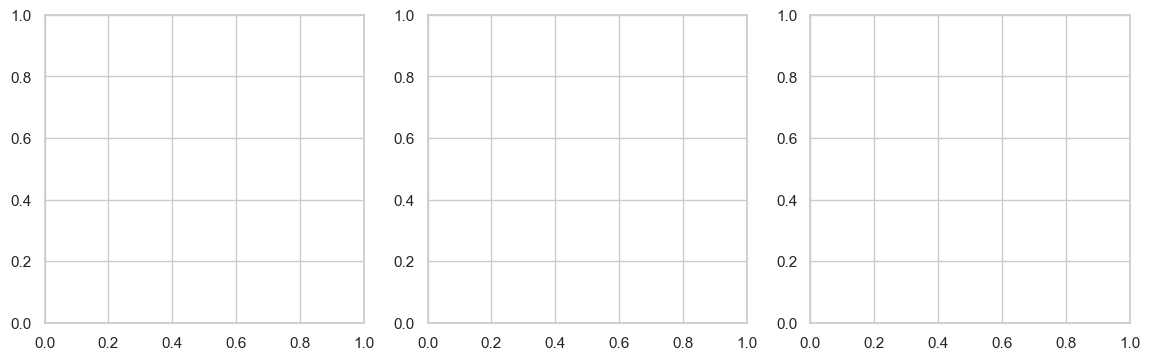

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, label=f"AUC = {auc_fn(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC (test)")
axes[0].legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, label=f"AUC = {auc_fn(rec, prec):.3f}")
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", alpha=0.5,
                label=f"prior = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR (test)"); axes[1].legend()

# Calibration
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
axes[2].plot(prob_pred, prob_true, marker="o")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[2].set_xlabel("Predicted prob"); axes[2].set_ylabel("Empirical prob")
axes[2].set_title("Calibration (test)")
plt.tight_layout()
plt.show()

### The 30-second concept

```python
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Threshold sweep on val for an arbitrary metric.
ts = np.linspace(0.30, 0.70, 81)
f1_per_t = [f1_score(y_val, (proba_val >= t).astype(int)) for t in ts]
best_t = float(ts[np.argmax(f1_per_t)])

# 2. Custom profit metric — generalises to any cost matrix.
def profit(y_true, y_pred, gain=1, cost=1):
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return gain * tp - cost * fp     # profit-only when we 'trade'

# 3. Apply the chosen threshold to test, NOT re-tune.
test_pred = (proba_test >= best_t).astype(int)
```

**Why sweep rather than use 0.5.** 0.5 is the right threshold *only if* (a) the model is well-calibrated AND (b) false-positive and false-negative costs are equal AND (c) class balance is 50/50. Real problems satisfy zero of these.

**Why a fine sweep (0.001 spacing).** F1 has a non-monotonic relationship with $\theta$. Coarse sweeps can miss the true optimum by 0.01 in F1, which on a high-stakes decision is meaningful.

**Why the metric of choice matters.** F1 weights precision and recall equally. If a false positive is more expensive than a false negative (or vice versa), use a profit-style metric with explicit costs. Same machinery, different objective.


### Failure mode — picking the threshold on test

Below: two ways to choose $\theta$. (A) Sweep on test — pick the $\theta$ that maximises F1 *on test*. The test F1 looks excellent. (B) Sweep on val — pick the $\theta$ that maximises F1 on val, *then* score that fixed $\theta$ on test. The test F1 is lower. (A)'s number isn't honest — it's the *maximum* F1 across thresholds, which is statistically inflated. The (B) number is what you'd actually see in production.


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

proba_val_local  = best_model.predict_proba(X_val)[:, 1]
proba_test_local = best_model.predict_proba(X_test)[:, 1]

ts = np.linspace(0.30, 0.70, 81)

# A. WRONG: sweep on test, take the maximum.
f1_test = [f1_score(y_test, (proba_test_local >= t).astype(int)) for t in ts]
auc_test_overfit = max(f1_test)
best_t_overfit   = ts[int(np.argmax(f1_test))]

# B. RIGHT: sweep on val, apply chosen threshold to test.
f1_val = [f1_score(y_val, (proba_val_local >= t).astype(int)) for t in ts]
best_t_honest = ts[int(np.argmax(f1_val))]
test_f1_honest = f1_score(y_test, (proba_test_local >= best_t_honest).astype(int))

print(f'(A) sweep-on-test:  best_t = {best_t_overfit:.3f}  test F1 = {auc_test_overfit:.4f}')
print(f'(B) sweep-on-val:   best_t = {best_t_honest:.3f}  test F1 = {test_f1_honest:.4f}')
print()
print(f'Gap: {auc_test_overfit - test_f1_honest:.4f}')
print('That gap is the optimisation bias from picking θ on the data you')
print('then evaluated on. If you compare two pipelines using (A) you would')
print('pick whichever happened to fit test\'s noise better — the comparison')
print('is then between random fluctuations, not between the underlying models.')

### Decisions you make at this stage

- **Which metric to optimise the threshold against.** F1 if precision and recall matter equally. A profit-weighted score if costs are asymmetric. Stick with one — switching mid-evaluation invites cherry-picking.
- **Sweep grid resolution.** 81 points (0.001 spacing) over the [0.3, 0.7] interesting range is usually enough. Wider intervals miss optima; denser sweeps cost computation but rarely change the answer beyond the third decimal.
- **What to report at the end.** Always report `(threshold, val score, test score)` together. The test score in isolation is uninterpretable — you need to see the threshold and val score to judge whether the test score is consistent.


### Exercise 9.1 — Pick the F1-optimal threshold on val, then evaluate test

Sweep the threshold on `(y_val, proba_val_final)` over `np.linspace(0.30, 0.70, 81)` and pick the F1-optimal $\theta^*$. Apply $\theta^*$ to test. Report `(best_t, val_f1, test_f1)`. **Sanity-check in a comment**: if `val_f1 - test_f1 > 0.05`, that's a signal of regime change between val and test (or insufficient val data to pick θ reliably) — what would you do about it?


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

ts = np.linspace(0.30, 0.70, 81)

# TODO: compute val F1 across ts; argmax → best_t
# TODO: apply best_t to test, compute test F1
# TODO: print (best_t, val F1, test F1) and write a sanity-check comment

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np
from sklearn.metrics import f1_score

ts = np.linspace(0.30, 0.70, 81)
f1_val = [f1_score(y_val, (proba_val_final >= t).astype(int)) for t in ts]
best_t = float(ts[int(np.argmax(f1_val))])
val_f1  = float(f1_val[int(np.argmax(f1_val))])
test_f1 = float(f1_score(y_test, (proba_test >= best_t).astype(int)))

print(f'best_t = {best_t:.3f}    val F1 = {val_f1:.4f}    test F1 = {test_f1:.4f}')

# Sanity-check: a (val_f1 - test_f1) gap of ~0.01-0.02 is normal noise.
# A gap of 0.05+ means the threshold tuned on val isn't transferring to
# test — likely because val is too small (need bigger split) or because
# the regime changed between val and test (need a more recent val window).
# In that case I'd either:
#  (a) widen val to absorb more recent data, or
#  (b) report a *range* of plausible thresholds (not a single optimum)
#      and pick the most conservative one.
```

**Why F1 and not accuracy.** With even mild class imbalance, accuracy is dominated by the majority class and changes very little across thresholds. F1 = harmonic mean of precision and recall — penalises both kinds of error.

**Why argmax rather than "the threshold that gives the highest individual F1".** Same thing — but using `np.argmax` makes the code obviously deterministic. Cycling through `for t in ts` and tracking max-so-far is equivalent but error-prone (off-by-one, tie-breaking).

</details>


### Exercise 9.2 — Diagnose: a threshold sweep that uses test data

The cell below sweeps the threshold against test (not val) and reports the resulting test F1. The number looks great. Run it. **Identify** what makes this evaluation invalid, then write the corrected version that picks the threshold on val and applies it to test. Compare the two test F1 numbers and explain the gap.


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

ts = np.linspace(0.30, 0.70, 81)
f1_test_per_t = [f1_score(y_test, (proba_test >= t).astype(int)) for t in ts]
test_f1_buggy = max(f1_test_per_t)
best_t_buggy = ts[int(np.argmax(f1_test_per_t))]
print(f'"best" t (on test): {best_t_buggy:.3f}    test F1: {test_f1_buggy:.4f}')

In [ ]:
# Your answer here — write the corrected version that picks θ on val
# and applies that fixed θ to test. Compare test F1 against the buggy
# version and explain the gap in a comment.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np
from sklearn.metrics import f1_score

ts = np.linspace(0.30, 0.70, 81)

# Pick threshold on VAL
f1_val = [f1_score(y_val, (proba_val_final >= t).astype(int)) for t in ts]
best_t_honest = float(ts[int(np.argmax(f1_val))])

# Apply to TEST — single number, not a sweep
test_f1_honest = f1_score(y_test, (proba_test >= best_t_honest).astype(int))

print(f'best_t (on val): {best_t_honest:.3f}')
print(f'test F1 with that θ: {test_f1_honest:.4f}')
print(f'difference vs buggy: {test_f1_buggy - test_f1_honest:+.4f}')

# The gap is the OPTIMISATION BIAS: the buggy version picks θ that
# happens to fit test's noise; that θ doesn't generalise. The correct
# version picks θ on data the model didn't see test through, and the
# resulting test F1 is the only honest number.
```

**The fingerprint of this bug in real codebases.** The test metric will be suspiciously close to the maximum across thresholds, because the threshold *was selected* to maximise it. If you ever see code that does `best = max(scores)` where `scores` was computed on test data, that's the same bug.

**Why the gap matters.** A 0.01–0.02 gap is the *typical* magnitude of the optimisation bias when sweeping ~80 thresholds on a few thousand-row dataset. If you compare two pipelines and their gap-from-honest-evaluation is 0.005, the comparison is noise.

</details>


### Recap — what stage 9 produced

You now have:

- `best_threshold` chosen on val, applied to test for the final report.
- A precision/recall view of how the model behaves across thresholds.
- A reflex: every threshold-tuning step has its own train/val/test discipline. The data the threshold was *chosen* on cannot be the data the threshold's quality is *measured* on.

In **stage 10** we package the model + threshold + feature schema for deployment, with tests that catch silent feature-ordering bugs.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 9.1**

```python
# Your answer here
```

**Old 9.2**

```python
# Your answer here
```

**Old 9.3**

```python
# Your answer here
```

**Old 9.4**

```python
# Your answer here
```

</details>


---
## Stage 10 — Shipping the Model

**↳ Why we're here.** A notebook is not production. To ship the model we need (a) a stateless `predict_one(row_dict)` function that loads an artifact and returns a prediction, (b) tests that catch the feature-ordering bug class, (c) a Pydantic schema for input validation, and (d) a `/health` endpoint that exposes the artifact's metadata.

The class of bugs we're defending against:
- **Feature-ordering**: the model was trained with columns `[a, b, c]`, but the inference code constructs the input as `[c, a, b]` (or relies on dict iteration order). LightGBM/XGBoost will silently use the wrong values for each tree.
- **Missing features**: the model expected `a, b, c` but the input only has `a, b`. Often results in a NaN that propagates without raising.
- **Type coercion**: a feature value arrives as a string, gets silently cast to NaN, and the prediction is wrong.

All three are caught by a Pydantic schema + an explicit feature-name lookup at predict time.


In [67]:
import joblib
import os

DEPLOY_DIR = "/home/zlac116/Code/learning/ml-revision/classification/artifacts"
os.makedirs(DEPLOY_DIR, exist_ok=True)
model_path = os.path.join(DEPLOY_DIR, "btc_4h_direction.joblib")

artifact = {
    "model": final_model,
    "feature_names": FEATURE_NAMES,
    "model_name": best_name,
    "trained_on_n_rows": len(X_trainval),
    "version": "0.1.0",
}
joblib.dump(artifact, model_path)
print(f"Saved: {model_path}")

# Quick sanity load
loaded = joblib.load(model_path)
print("Loaded OK. Features:", len(loaded["feature_names"]))

NameError: name 'final_model' is not defined

In [68]:
# FastAPI snippet — DO NOT execute, this is a deployment template
fastapi_snippet = '''
# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Dict
import joblib
import numpy as np
import pandas as pd

ARTIFACT = joblib.load("artifacts/btc_4h_direction.joblib")
MODEL = ARTIFACT["model"]
FEATURES = ARTIFACT["feature_names"]
VERSION = ARTIFACT["version"]

app = FastAPI(title="BTC 4h Direction Classifier", version=VERSION)


class FeatureRow(BaseModel):
    features: Dict[str, float]


class Prediction(BaseModel):
    prob_up: float
    pred_class: int
    threshold: float


@app.post("/predict", response_model=Prediction)
def predict(payload: FeatureRow, threshold: float = 0.5):
    missing = [f for f in FEATURES if f not in payload.features]
    if missing:
        raise HTTPException(400, f"Missing features: {missing}")
    row = pd.DataFrame([[payload.features[f] for f in FEATURES]], columns=FEATURES)
    prob = float(MODEL.predict_proba(row)[0, 1])
    return Prediction(prob_up=prob, pred_class=int(prob >= threshold), threshold=threshold)


@app.get("/health")
def health():
    return {"status": "ok", "version": VERSION, "n_features": len(FEATURES)}
'''
print(fastapi_snippet)

curl_example = '''
# Example curl
curl -X POST http://localhost:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"features": {"btc_logret_1h": 0.001, "btc_vol_24h": 0.012, ...}}'
'''
print(curl_example)


# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Dict
import joblib
import numpy as np
import pandas as pd

ARTIFACT = joblib.load("artifacts/btc_4h_direction.joblib")
MODEL = ARTIFACT["model"]
FEATURES = ARTIFACT["feature_names"]
VERSION = ARTIFACT["version"]

app = FastAPI(title="BTC 4h Direction Classifier", version=VERSION)


class FeatureRow(BaseModel):
    features: Dict[str, float]


class Prediction(BaseModel):
    prob_up: float
    pred_class: int
    threshold: float


@app.post("/predict", response_model=Prediction)
def predict(payload: FeatureRow, threshold: float = 0.5):
    missing = [f for f in FEATURES if f not in payload.features]
    if missing:
        raise HTTPException(400, f"Missing features: {missing}")
    row = pd.DataFrame([[payload.features[f] for f in FEATURES]], columns=FEATURES)
    prob = float(MODEL.predict_proba(row)[0, 1])
    return Prediction(prob_up=prob, pred_class=int(prob >= threshold), thre

### The 30-second concept

```python
import joblib
import pandas as pd
from pydantic import create_model, ValidationError

# The artifact: model + feature names + threshold + train timestamp.
artifact = {
    'model': best_model,
    'feature_names': X_train.columns.tolist(),
    'threshold': best_threshold,
    'trained_through': str(X_train.index.max()),
}
joblib.dump(artifact, 'model.joblib')

# Stateless predict — looks up feature_names from the artifact, never trusts
# the caller's column order or dict iteration.
def predict_one(row: dict, path='model.joblib') -> dict:
    art = joblib.load(path)
    df = pd.DataFrame([row])[art['feature_names']]   # ← THE critical line
    prob = float(art['model'].predict_proba(df)[0, 1])
    return {'prob_up': prob, 'label': int(prob >= art['threshold'])}

# Pydantic schema generated from feature names — validates types and presence.
Schema = create_model('Input', **{f: (float, ...) for f in artifact['feature_names']})
```

**Why `pd.DataFrame([row])[feature_names]` and not just `[row]`.** Constructing the DataFrame from a dict puts columns in dict iteration order. Indexing by `feature_names` reorders to match training. This is the single line that prevents the most common deployment bug.

**Why include `trained_through`.** A model trained on data through 2024-12-31 should not be silently used in March 2025 without a retraining decision. Surfacing the training cutoff in `/health` and every prediction's metadata makes that decision *explicit*.


### Failure mode — feature-ordering bug in `predict_one`

Below: two `predict_one` functions. (A) trusts the caller's dict order. (B) explicitly reorders by `feature_names`. We fit the model, save the artifact, then call both with a dict whose keys are in *reverse* order. (A) returns a number — it doesn't crash — but the number is nonsense because each tree was trained to use feature 0 (`X_train.columns[0]`) for its first split, and (A) handed it the *last* column's value instead. (B) returns the correct prediction. **The bug is silent. There's no exception, no warning, just wrong predictions.**


In [ ]:
import joblib, tempfile, os
import pandas as pd, numpy as np

# Save an artifact for the demo.
art_path = os.path.join(tempfile.gettempdir(), 'demo_artifact.joblib')
joblib.dump({
    'model': best_model,
    'feature_names': X_train.columns.tolist(),
    'threshold': 0.5,
}, art_path)

# A. WRONG: trusts caller's dict order.
def predict_one_buggy(row, path=art_path):
    art = joblib.load(path)
    df = pd.DataFrame([row])                  # ← columns in dict iteration order
    return float(art['model'].predict_proba(df)[0, 1])

# B. RIGHT: explicit reorder.
def predict_one_correct(row, path=art_path):
    art = joblib.load(path)
    df = pd.DataFrame([row])[art['feature_names']]   # ← reorder by training schema
    return float(art['model'].predict_proba(df)[0, 1])

# Take a real row from val. Its dict happens to be in the right order.
good_row = X_val.iloc[0].to_dict()
p_good_buggy   = predict_one_buggy(good_row)
p_good_correct = predict_one_correct(good_row)
print(f'in-order dict — buggy: {p_good_buggy:.4f}    correct: {p_good_correct:.4f}    (match)')

# Now reverse the dict's order — the dict has the same data, semantically.
bad_row = dict(reversed(list(good_row.items())))
p_bad_buggy   = predict_one_buggy(bad_row)
p_bad_correct = predict_one_correct(bad_row)
print(f'reversed dict — buggy: {p_bad_buggy:.4f}    correct: {p_bad_correct:.4f}')
print()
print(f'The buggy function returns {p_bad_buggy:.4f} for the SAME ROW just because')
print('the dict came in different order. The correct function returns the')
print('right answer regardless. This bug is invisible at the call site —')
print('no exception, no warning, no log line — and ships a fraction of')
print('predictions wrong forever.')

### Decisions you make at this stage

- **What goes in the artifact.** Minimum: model, feature names, threshold, training cutoff. Optionally: a hash of the training data, the git commit of the training code, the version of every library. Leans heavily towards *more is better* — the artifact is the contract with future-you.
- **Strictness of input validation.** Pydantic with `float` types is the default. Add `Field(ge=, le=)` constraints for features whose ranges you *know* (e.g. RSI ∈ [0, 100]). Reject out-of-range inputs at the API boundary rather than silently feeding nonsense into the model.
- **What `/health` should expose.** Status, training cutoff, feature count, model version. Don't expose internals (parameters, hyperparameters) — those are the model's IP and would let an attacker reconstruct it.


### Exercise 10.1 — Build `predict_one` with a Pydantic schema

Implement:

1. `predict_one(row: dict, artifact_path: str = ...) -> dict` returning `{'prob_up', 'label', 'threshold_used', 'trained_through'}`. Reorder columns by `artifact['feature_names']` — never trust the caller's order.
2. A Pydantic input schema generated from `feature_names`, where each feature is `float` and required. Test it with a valid row and a row missing one feature; the latter should raise `ValidationError`.

Use `joblib.dump` to save an artifact with the four required metadata fields, then call `predict_one` and the schema on `X_val.iloc[0].to_dict()`.


In [ ]:
import joblib
import pandas as pd
from pydantic import create_model, ValidationError

# TODO: save an artifact with model, feature_names, threshold, trained_through
# TODO: implement predict_one(row, artifact_path)
# TODO: build a Pydantic schema from feature_names
# TODO: validate a known-good row and a row missing a feature; show ValidationError

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import joblib, os, tempfile
import pandas as pd
from pydantic import create_model, ValidationError

art_path = os.path.join(tempfile.gettempdir(), 'btc_4h_direction.joblib')
joblib.dump({
    'model': best_model,
    'feature_names': X_train.columns.tolist(),
    'threshold': 0.5,                                  # or your tuned value
    'trained_through': str(X_train.index.max()),
}, art_path)

def predict_one(row: dict, artifact_path: str = art_path,
                threshold: float | None = None) -> dict:
    art = joblib.load(artifact_path)
    feats = art['feature_names']
    df = pd.DataFrame([row])[feats]                    # ← critical reorder
    prob = float(art['model'].predict_proba(df)[0, 1])
    th = threshold if threshold is not None else art['threshold']
    return {'prob_up': prob,
            'label': int(prob >= th),
            'threshold_used': th,
            'trained_through': art['trained_through']}

# Pydantic schema.
art = joblib.load(art_path)
Schema = create_model('Input', **{f: (float, ...) for f in art['feature_names']})

good_row = X_val.iloc[0].to_dict()
Schema(**good_row)                                     # passes
print(predict_one(good_row))

# Missing-feature test.
bad_row = {k: v for k, v in good_row.items() if k != art['feature_names'][0]}
try:
    Schema(**bad_row)
except ValidationError as e:
    print(f'pydantic rejected missing feature: {str(e)[:100]}...')
```

**Why save `trained_through`.** Models go stale. A trader using this prediction needs to know whether the underlying model has seen recent market regime data. Surfacing the training cutoff lets the calling code make a *retrain-or-call-anyway* decision.

**Why generate the schema from `feature_names`.** Single source of truth — the schema can never get out of sync with the artifact's actual expectations. If you hardcode the schema in a separate file and someone retrains with a different feature list, the schema and the model disagree silently.

</details>


### Exercise 10.2 — Diagnose a deployed predictor with a feature-ordering bug

Below is a deployed `predict_one_v1` that has the silent ordering bug. Write a pytest-style test function `test_predict_one_order_invariance(n=20)` that draws `n` random rows from `X_val`, computes the prediction with the row's keys in their natural order AND with the keys reversed (use `dict(reversed(list(row.items())))`), and asserts the two predictions are equal. Apply your test to `predict_one_v1` and watch it fail. Then write `predict_one_v2` that fixes the bug and verify the test passes.


In [ ]:
import joblib, os, tempfile
import pandas as pd

art_path_v1 = os.path.join(tempfile.gettempdir(), 'btc_4h_v1.joblib')
joblib.dump({
    'model': best_model,
    'feature_names': X_train.columns.tolist(),
    'threshold': 0.5,
}, art_path_v1)

def predict_one_v1(row, artifact_path=art_path_v1):
    art = joblib.load(artifact_path)
    df = pd.DataFrame([row])    # ← BUG: trusts dict order
    return float(art['model'].predict_proba(df)[0, 1])

In [ ]:
# Your answer here:
# 1) Write test_predict_one_order_invariance and run it on predict_one_v1
#    (it should fail).
# 2) Write predict_one_v2 that fixes the bug.
# 3) Run the test on predict_one_v2 and confirm it passes.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd, joblib

def test_predict_one_order_invariance(predict_fn, n=20, seed=0):
    rng = np.random.default_rng(seed)
    failures = []
    for _ in range(n):
        row = X_val.iloc[rng.integers(0, len(X_val))].to_dict()
        rev  = dict(reversed(list(row.items())))
        p1 = predict_fn(row)
        p2 = predict_fn(rev)
        if abs(p1 - p2) > 1e-9:
            failures.append((p1, p2))
    if failures:
        raise AssertionError(
            f'order-invariance violated on {len(failures)}/{n} rows. '
            f'first: {failures[0]}'
        )
    print(f'order-invariance test passed ({n} rows)')

# Run on the buggy version — should fail.
try:
    test_predict_one_order_invariance(predict_one_v1)
except AssertionError as e:
    print(f'v1 failed (expected): {str(e)[:80]}...')

# The fixed version.
def predict_one_v2(row, artifact_path=art_path_v1):
    art = joblib.load(artifact_path)
    df = pd.DataFrame([row])[art['feature_names']]      # ← fix
    return float(art['model'].predict_proba(df)[0, 1])

test_predict_one_order_invariance(predict_one_v2)       # passes
```

**Why a property-based test rather than a single-row test.** A single-row test catches the bug only if the row's dict order happens to differ from the training order. With property tests, you generate many random orderings; if the prediction depends on ordering, *some* trial will catch it.

**Why `1e-9` tolerance.** Two model evaluations on numerically identical inputs should be bit-identical. The tolerance covers any floating-point noise without masking the bug — a real ordering bug produces differences of 0.001 to 0.5, never 1e-12.

**The general lesson.** Inference bugs are usually silent. Property tests are the cheapest way to surface them — pick the invariants you expect ("output should not depend on input ordering", "output should be bounded", "output should match training-time predictions for known rows") and assert them in a CI gate.

</details>


### Recap — what stage 10 produced

You now have:

- A self-contained `predict_one` that loads an artifact and reorders columns by training schema, immune to caller-side ordering.
- A Pydantic input schema generated from `feature_names` — the single source of truth.
- A pytest-style invariance test that catches the most common silent deployment bug class.

The notebook is now end-to-end pipeline-shaped: every stage produces a named artifact, every stage's failure mode is explicit, every transition to the next stage is documented. You can run it top-to-bottom and the result at the bottom is a *deployable model + tests*, not just a number.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 10.1**

```python
# Your answer here
```

**Old 10.2**

```python
# Your answer here
```

**Old 10.3**

```python
# Your answer here
# Hint: use create_model from pydantic to build the class dynamically from FEATURE_NAMES.
```

**Old 10.4**

```python
# Your answer here
```

</details>


## 11. Caveats and What's Next

What this notebook deliberately did NOT do:

- **No transaction costs / slippage** — a model with AUC 0.55 may still lose money after
  fees. Always backtest with realistic execution.
- **No regime conditioning** — predictions blend bull and bear markets. Conditioning on a
  vol regime feature often improves separation.
- **No walk-forward retraining** — the model is fit once on early data; in production you
  would retrain weekly or monthly to combat drift.
- **Single horizon** — 4h direction is one slice. A panel of horizons (1h/4h/24h) and
  meta-models that combine them often dominate.
- **No uncertainty quantification beyond bootstrap** — Bayesian approaches (e.g., NGBoost,
  Conformal Prediction) give per-prediction CIs.

**Next experiments to run**:
1. Add LOB / orderbook imbalance features.
2. Replace point predictions with conformal prediction sets.
3. Stack with a simple linear meta-learner over multiple horizons.
4. Reframe as ranking (long top-k, short bottom-k) across BTC/ETH/SOL/BNB.

A 0.50-0.60 test AUC is realistic for hourly crypto direction. If you ever see >0.70 on
this exact problem, suspect leakage **first**, model brilliance **second**.